<a href="https://colab.research.google.com/github/dwii3830-spec/Jawaban-Soal-MetNumerik-11.1-11.28/blob/main/Jawaban%20dalam%20kode%20py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Soal 11.1 - Thomas Algorithm untuk sistem tridiagonal

In [ ]:
"""
Sistem:
 0.8*x1 - 0.4*x2              = 41
-0.4*x1 + 0.8*x2 - 0.4*x3    = 25
          -0.4*x2 + 0.8*x3    = 105
"""
import numpy as np

def thomas_algorithm(a, b, c, d):
    """
    Thomas algorithm untuk sistem tridiagonal.
    a = sub-diagonal, b = main diagonal, c = super-diagonal, d = RHS
    """
    n = len(d)
    # Salin agar tidak merusak array asli
    b = b.copy().astype(float)
    d = d.copy().astype(float)
    c = c.copy().astype(float)

    # Forward sweep
    for i in range(1, n):
        factor = a[i-1] / b[i-1]
        b[i] -= factor * c[i-1]
        d[i] -= factor * d[i-1]

    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

# Definisi sistem (3x3 tridiagonal)
# [0.8  -0.4   0 ] [x1]   [41 ]
# [-0.4  0.8 -0.4] [x2] = [25 ]
# [0   -0.4  0.8 ] [x3]   [105]

a = np.array([-0.4, -0.4])        # sub-diagonal (elemen [1,0] dan [2,1])
b = np.array([0.8, 0.8, 0.8])     # main diagonal
c = np.array([-0.4, -0.4])        # super-diagonal (elemen [0,1] dan [1,2])
d = np.array([41.0, 25.0, 105.0]) # RHS

x = thomas_algorithm(a, b, c, d)

print("=" * 45)
print("Soal 11.1 - Thomas Algorithm (Tridiagonal)")
print("=" * 45)
print(f"x1 = {x[0]:.6f}")
print(f"x2 = {x[1]:.6f}")
print(f"x3 = {x[2]:.6f}")

# Verifikasi dengan numpy
A = np.array([[0.8, -0.4, 0],
              [-0.4, 0.8, -0.4],
              [0, -0.4, 0.8]])
b_vec = np.array([41.0, 25.0, 105.0])
x_np = np.linalg.solve(A, b_vec)
print("\nVerifikasi dengan numpy.linalg.solve:")
print(f"x1 = {x_np[0]:.6f}, x2 = {x_np[1]:.6f}, x3 = {x_np[2]:.6f}")
print("\nResidual (Ax - b):", np.linalg.norm(A @ x - b_vec))

Soal 11.1 - Thomas Algorithm (Tridiagonal)
x1 = 173.750000
x2 = 245.000000
x3 = 253.750000

Verifikasi dengan numpy.linalg.solve:
x1 = 173.750000, x2 = 245.000000, x3 = 253.750000

Residual (Ax - b): 1.7404671430534633e-14


Soal 11.2 - Invers matriks menggunakan dekomposisi LU dan unit vectors
Berdasarkan sistem dari Example 11.1:

In [ ]:
"""
Example 11.1:
[A] = [[0.8, -0.4, 0], [-0.4, 0.8, -0.4], [0, -0.4, 0.8]]
"""
import numpy as np
from scipy.linalg import lu

def lu_inverse(A):
    """Hitung invers matriks menggunakan dekomposisi LU dan unit vectors."""
    n = A.shape[0]
    A_inv = np.zeros((n, n))
    # Unit vectors sebagai RHS
    for i in range(n):
        e = np.zeros(n)
        e[i] = 1.0
        A_inv[:, i] = np.linalg.solve(A, e)
    return A_inv

A = np.array([[0.8, -0.4, 0.0],
              [-0.4, 0.8, -0.4],
              [0.0, -0.4, 0.8]])

A_inv = lu_inverse(A)

print("=" * 50)
print("Soal 11.2 - Invers Matriks via LU Decomposition")
print("=" * 50)
print("\nMatriks A:")
print(A)
print("\nInvers A (via LU + unit vectors):")
print(np.round(A_inv, 6))

# Verifikasi: A @ A_inv = I
product = A @ A_inv
print("\nVerifikasi A @ A_inv (seharusnya = I):")
print(np.round(product, 10))

# Bandingkan dengan numpy
print("\nInvers A (via numpy):")
print(np.round(np.linalg.inv(A), 6))

Soal 11.2 - Invers Matriks via LU Decomposition

Matriks A:
[[ 0.8 -0.4  0. ]
 [-0.4  0.8 -0.4]
 [ 0.  -0.4  0.8]]

Invers A (via LU + unit vectors):
[[1.875 1.25  0.625]
 [1.25  2.5   1.25 ]
 [0.625 1.25  1.875]]

Verifikasi A @ A_inv (seharusnya = I):
[[ 1.  0. -0.]
 [-0.  1. -0.]
 [-0. -0.  1.]]

Invers A (via numpy):
[[1.875 1.25  0.625]
 [1.25  2.5   1.25 ]
 [0.625 1.25  1.875]]


Soal 11.3 - Thomas Algorithm untuk sistem tridiagonal 4x4 (Crank-Nicolson)

In [ ]:
"""
Thomas Algorithm untuk sistem tridiagonal 4x4 (Crank-Nicolson)
[2.01475  -0.020875   0          0       ] [T1]   [4.175 ]
[-0.020875  2.01475  -0.020875   0       ] [T2] = [0     ]
[0         -0.020875  2.01475   -0.020875] [T3]   [0     ]
[0          0        -0.020875   2.01475 ] [T4]   [2.0875]
"""
import numpy as np

def thomas_algorithm(a, b, c, d):
    n = len(d)
    b = b.copy().astype(float)
    d = d.copy().astype(float)
    c = c.copy().astype(float)
    for i in range(1, n):
        factor = a[i-1] / b[i-1]
        b[i] -= factor * c[i-1]
        d[i] -= factor * d[i-1]
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

a = np.array([-0.020875, -0.020875, -0.020875])   # sub-diagonal
b = np.array([2.01475, 2.01475, 2.01475, 2.01475]) # main diagonal
c = np.array([-0.020875, -0.020875, -0.020875])    # super-diagonal
d = np.array([4.175, 0.0, 0.0, 2.0875])            # RHS

T = thomas_algorithm(a, b, c, d)

print("=" * 55)
print("Soal 11.3 - Thomas Algorithm (Crank-Nicolson 4x4)")
print("=" * 55)
for i, t in enumerate(T, 1):
    print(f"T{i} = {t:.6f}")

# Verifikasi
A = np.array([[ 2.01475, -0.020875,  0,         0        ],
              [-0.020875,  2.01475, -0.020875,  0        ],
              [ 0,       -0.020875,  2.01475,  -0.020875 ],
              [ 0,        0,        -0.020875,  2.01475  ]])
b_vec = np.array([4.175, 0.0, 0.0, 2.0875])
print("\nResidual (Ax - b):", np.linalg.norm(A @ T - b_vec))

Soal 11.3 - Thomas Algorithm (Crank-Nicolson 4x4)
T1 = 2.072441
T2 = 0.021586
T3 = 0.010960
T4 = 1.036222

Residual (Ax - b): 3.469446951953614e-18


Soal 11.4 - Verifikasi Cholesky Decomposition dari Example 11.2
Membuktikan bahwa [L][L]^T = [A]
Matriks dari Example 11.2

In [ ]:
"""
Example 11.2:
[A] = [[2, 1, 1], [1, 3, 2], [1, 2, 2]]
"""
import numpy as np

def cholesky_decomposition(A):
    """Dekomposisi Cholesky manual."""
    n = A.shape[0]
    L = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1):
            s = sum(L[i][k] * L[j][k] for k in range(j))
            if i == j:
                val = A[i][i] - s
                if val <= 0:
                    raise ValueError("Matriks tidak positif definit!")
                L[i][j] = np.sqrt(val)
            else:
                L[i][j] = (A[i][j] - s) / L[j][j]
    return L

# Matriks simetris positif definit (Example 11.2 dari buku)
A = np.array([[2.0, 1.0, 1.0],
              [1.0, 3.0, 2.0],
              [1.0, 2.0, 2.0]])

print("=" * 50)
print("Soal 11.4 - Verifikasi Cholesky Decomposition")
print("=" * 50)
print("\nMatriks A:")
print(A)

L = cholesky_decomposition(A)
print("\nMatriks L (lower triangular):")
print(np.round(L, 6))

LLT = L @ L.T
print("\n[L][L]^T =")
print(np.round(LLT, 6))

print("\nApakah [L][L]^T == [A]?", np.allclose(LLT, A))
print("Error maksimum:", np.max(np.abs(LLT - A)))

Soal 11.4 - Verifikasi Cholesky Decomposition

Matriks A:
[[2. 1. 1.]
 [1. 3. 2.]
 [1. 2. 2.]]

Matriks L (lower triangular):
[[1.414214 0.       0.      ]
 [0.707107 1.581139 0.      ]
 [0.707107 0.948683 0.774597]]

[L][L]^T =
[[2. 1. 1.]
 [1. 3. 2.]
 [1. 2. 2.]]

Apakah [L][L]^T == [A]? True
Error maksimum: 4.440892098500626e-16


Soal 11.5 - Cholesky Decomposition untuk sistem simetris

In [ ]:
"""
Cholesky Decomposition untuk sistem simetris
[A] = [[6, 15, 55], [15, 55, 225], [55, 225, 979]]
{b} = [152.6, 585.6, 2488.8]
"""
import numpy as np

def cholesky_decomposition(A):
    n = A.shape[0]
    L = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1):
            s = sum(L[i][k] * L[j][k] for k in range(j))
            if i == j:
                L[i][j] = np.sqrt(A[i][i] - s)
            else:
                L[i][j] = (A[i][j] - s) / L[j][j]
    return L

def forward_substitution(L, b):
    n = len(b)
    y = np.zeros(n)
    for i in range(n):
        y[i] = (b[i] - sum(L[i][j]*y[j] for j in range(i))) / L[i][i]
    return y

def back_substitution(U, y):
    n = len(y)
    x = np.zeros(n)
    for i in range(n-1, -1, -1):
        x[i] = (y[i] - sum(U[i][j]*x[j] for j in range(i+1, n))) / U[i][i]
    return x

A = np.array([[6.0,  15.0,   55.0],
              [15.0,  55.0,  225.0],
              [55.0, 225.0,  979.0]])
b = np.array([152.6, 585.6, 2488.8])

print("=" * 50)
print("Soal 11.5 - Cholesky Decomposition")
print("=" * 50)
print("\nMatriks A:")
print(A)

L = cholesky_decomposition(A)
print("\nMatriks L:")
print(np.round(L, 6))
print("\nMatriks L^T:")
print(np.round(L.T, 6))

# Solve L*y = b, lalu L^T*x = y
y = forward_substitution(L, b)
a_sol = back_substitution(L.T, y)

print("\nSolusi (a0, a1, a2):")
for i, v in enumerate(a_sol):
    print(f"a{i} = {v:.6f}")

print("\nVerifikasi (Ax - b):", np.round(A @ a_sol - b, 8))

Soal 11.5 - Cholesky Decomposition

Matriks A:
[[  6.  15.  55.]
 [ 15.  55. 225.]
 [ 55. 225. 979.]]

Matriks L:
[[ 2.44949   0.        0.      ]
 [ 6.123724  4.1833    0.      ]
 [22.453656 20.916501  6.110101]]

Matriks L^T:
[[ 2.44949   6.123724 22.453656]
 [ 0.        4.1833   20.916501]
 [ 0.        0.        6.110101]]

Solusi (a0, a1, a2):
a0 = 2.478571
a1 = 2.359286
a2 = 1.860714

Verifikasi (Ax - b): [0. 0. 0.]


Soal 11.7 - Cholesky Decomposition dari matriks diagonal

In [ ]:
"""
Cholesky Decomposition dari matriks diagonal
[A] = [[9,0,0],[0,25,0],[0,0,4]]
Berdasarkan Eq. (11.3) dan (11.4): L_ii = sqrt(A_ii) untuk matriks diagonal
"""
import numpy as np

A = np.array([[9.0, 0.0, 0.0],
              [0.0, 25.0, 0.0],
              [0.0, 0.0, 4.0]])

print("=" * 55)
print("Soal 11.7 - Cholesky dari Matriks Diagonal")
print("=" * 55)
print("\nMatriks A (diagonal):")
print(A)

L = np.linalg.cholesky(A)
print("\nMatriks L (Cholesky):")
print(L)

print("\nInterpretasi:")
print("Untuk matriks diagonal, L_ii = sqrt(A_ii) dan L_ij = 0 (i≠j)")
print(f"  L[1,1] = sqrt(9)  = {np.sqrt(9)}")
print(f"  L[2,2] = sqrt(25) = {np.sqrt(25)}")
print(f"  L[3,3] = sqrt(4)  = {np.sqrt(4)}")
print("\nHasil ini sesuai dengan Eq. (11.3): L_jj = sqrt(A_jj - sum(L_jk^2))")
print("  karena tidak ada off-diagonal elements, semua L_jk = 0 untuk k < j")

print("\nVerifikasi L @ L^T == A:", np.allclose(L @ L.T, A))

Soal 11.7 - Cholesky dari Matriks Diagonal

Matriks A (diagonal):
[[ 9.  0.  0.]
 [ 0. 25.  0.]
 [ 0.  0.  4.]]

Matriks L (Cholesky):
[[3. 0. 0.]
 [0. 5. 0.]
 [0. 0. 2.]]

Interpretasi:
Untuk matriks diagonal, L_ii = sqrt(A_ii) dan L_ij = 0 (i≠j)
  L[1,1] = sqrt(9)  = 3.0
  L[2,2] = sqrt(25) = 5.0
  L[3,3] = sqrt(4)  = 2.0

Hasil ini sesuai dengan Eq. (11.3): L_jj = sqrt(A_jj - sum(L_jk^2))
  karena tidak ada off-diagonal elements, semua L_jk = 0 untuk k < j

Verifikasi L @ L^T == A: True


Soal 11.8 - Gauss-Seidel dengan overrelaxation (λ=1.2) untuk sistem 11.1

In [ ]:
"""
Sistem:
 0.8*x1 - 0.4*x2              = 41
-0.4*x1 + 0.8*x2 - 0.4*x3    = 25
          -0.4*x2 + 0.8*x3    = 105
Toleransi: es = 5%
"""
import numpy as np

def gauss_seidel_relaxation(A, b, lam=1.0, es=0.05, max_iter=100):
    n = len(b)
    x = np.zeros(n)
    print(f"\nIterasi Gauss-Seidel (λ={lam}, es={es*100}%):")
    print(f"{'Iter':>5} {'x1':>12} {'x2':>12} {'x3':>12} {'Max Error':>12}")
    for it in range(1, max_iter+1):
        x_old = x.copy()
        for i in range(n):
            sigma = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new = (b[i] - sigma) / A[i][i]
            x[i] = lam * x_new + (1 - lam) * x_old[i]
        # Hitung error
        errors = [abs((x[i] - x_old[i]) / x[i]) * 100 if x[i] != 0 else 0 for i in range(n)]
        max_err = max(errors)
        print(f"{it:>5} {x[0]:>12.6f} {x[1]:>12.6f} {x[2]:>12.6f} {max_err:>12.4f}%")
        if max_err < es * 100:
            print(f"\nKonvergen setelah {it} iterasi.")
            return x, it
    print("\nTidak konvergen dalam iterasi maksimum.")
    return x, max_iter

A = np.array([[0.8, -0.4, 0.0],
              [-0.4, 0.8, -0.4],
              [0.0, -0.4, 0.8]])
b = np.array([41.0, 25.0, 105.0])

print("=" * 65)
print("Soal 11.8 - Gauss-Seidel dengan Overrelaxation (λ=1.2)")
print("=" * 65)

x, n_iter = gauss_seidel_relaxation(A, b, lam=1.2, es=0.05)
print(f"\nSolusi akhir: x1={x[0]:.6f}, x2={x[1]:.6f}, x3={x[2]:.6f}")
print("Solusi eksak (numpy):", np.round(np.linalg.solve(A, b), 6))

Soal 11.8 - Gauss-Seidel dengan Overrelaxation (λ=1.2)

Iterasi Gauss-Seidel (λ=1.2, es=5.0%):
 Iter           x1           x2           x3    Max Error
    1    61.500000    74.400000   202.140000     100.0000%
    2    93.840000   200.208000   237.196800      62.8386%
    3   162.856800   237.490560   252.554976      42.3788%
    4   171.422976   244.388659   253.622200       4.9971%

Konvergen setelah 4 iterasi.

Solusi akhir: x1=171.422976, x2=244.388659, x3=253.622200
Solusi eksak (numpy): [173.75 245.   253.75]


Soal 11.9 - Gauss-Seidel untuk sistem reaktor berpasangan

In [ ]:
"""
Gauss-Seidel untuk sistem reaktor berpasangan
 15c1 -  3c2 -   c3 = 3800
 -3c1 + 18c2 -  6c3 = 1200
 -4c1 -   c2 + 12c3 = 2350
Toleransi: es = 5%
"""
import numpy as np

def gauss_seidel(A, b, es=0.05, max_iter=100):
    n = len(b)
    x = np.zeros(n)
    print(f"\n{'Iter':>5} {'c1':>12} {'c2':>12} {'c3':>12} {'Max Error':>12}")
    for it in range(1, max_iter+1):
        x_old = x.copy()
        for i in range(n):
            sigma = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x[i] = (b[i] - sigma) / A[i][i]
        errors = [abs((x[i] - x_old[i]) / x[i]) * 100 if x[i] != 0 else 0 for i in range(n)]
        max_err = max(errors)
        print(f"{it:>5} {x[0]:>12.4f} {x[1]:>12.4f} {x[2]:>12.4f} {max_err:>12.4f}%")
        if max_err < es * 100:
            print(f"\nKonvergen setelah {it} iterasi.")
            return x
    return x

A = np.array([[15.0, -3.0, -1.0],
              [-3.0, 18.0, -6.0],
              [-4.0, -1.0, 12.0]])
b = np.array([3800.0, 1200.0, 2350.0])

print("=" * 60)
print("Soal 11.9 - Gauss-Seidel untuk Sistem Reaktor")
print("=" * 60)

# Cek diagonal dominance
for i in range(3):
    diag = abs(A[i][i])
    off = sum(abs(A[i][j]) for j in range(3) if j != i)
    print(f"Baris {i+1}: |a_ii|={diag} vs sum|a_ij|={off} -> {'dominan' if diag > off else 'tidak dominan'}")

x = gauss_seidel(A, b, es=0.05)
print(f"\nKonsentrasi: c1={x[0]:.4f}, c2={x[1]:.4f}, c3={x[2]:.4f} g/m^3")
print("Solusi eksak:", np.round(np.linalg.solve(A, b), 4))

Soal 11.9 - Gauss-Seidel untuk Sistem Reaktor
Baris 1: |a_ii|=15.0 vs sum|a_ij|=4.0 -> dominan
Baris 2: |a_ii|=18.0 vs sum|a_ij|=9.0 -> dominan
Baris 3: |a_ii|=12.0 vs sum|a_ij|=5.0 -> dominan

 Iter           c1           c2           c3    Max Error
    1     253.3333     108.8889     289.3519     100.0000%
    2     294.4012     212.1842     311.6491      48.6819%
    3     316.5468     223.3075     319.9579       6.9960%
    4     319.3254     226.5402     321.1535       1.4270%

Konvergen setelah 4 iterasi.

Konsentrasi: c1=319.3254, c2=226.5402, c3=321.1535 g/m^3
Solusi eksak: [320.2073 227.2021 321.5026]


Soal 11.10 - Jacobi Iteration untuk sistem reaktor (Prob. 11.9)

In [ ]:
"""
Jacobi Iteration untuk sistem reaktor (Prob. 11.9)
 15c1 -  3c2 -   c3 = 3800
 -3c1 + 18c2 -  6c3 = 1200
 -4c1 -   c2 + 12c3 = 2350
Toleransi: es = 5%
"""
import numpy as np

def jacobi_iteration(A, b, es=0.05, max_iter=100):
    n = len(b)
    x = np.zeros(n)
    print(f"\n{'Iter':>5} {'c1':>12} {'c2':>12} {'c3':>12} {'Max Error':>12}")
    for it in range(1, max_iter+1):
        x_new = np.zeros(n)
        for i in range(n):
            sigma = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - sigma) / A[i][i]
        errors = [abs((x_new[i] - x[i]) / x_new[i]) * 100 if x_new[i] != 0 else 0 for i in range(n)]
        max_err = max(errors)
        print(f"{it:>5} {x_new[0]:>12.4f} {x_new[1]:>12.4f} {x_new[2]:>12.4f} {max_err:>12.4f}%")
        x = x_new
        if max_err < es * 100:
            print(f"\nKonvergen setelah {it} iterasi.")
            return x
    print("\nBelum konvergen dalam batas maksimum.")
    return x

A = np.array([[15.0, -3.0, -1.0],
              [-3.0, 18.0, -6.0],
              [-4.0, -1.0, 12.0]])
b = np.array([3800.0, 1200.0, 2350.0])

print("=" * 60)
print("Soal 11.10 - Jacobi Iteration untuk Sistem Reaktor")
print("=" * 60)

x = jacobi_iteration(A, b, es=0.05)
print(f"\nKonsentrasi: c1={x[0]:.4f}, c2={x[1]:.4f}, c3={x[2]:.4f} g/m^3")
print("Solusi eksak:", np.round(np.linalg.solve(A, b), 4))

Soal 11.10 - Jacobi Iteration untuk Sistem Reaktor

 Iter           c1           c2           c3    Max Error
    1     253.3333      66.6667     195.8333     100.0000%
    2     279.7222     174.1667     285.8333      61.7225%
    3     307.2222     208.5648     303.5880      16.4928%
    4     315.2855     219.0664     315.6211       4.7938%

Konvergen setelah 4 iterasi.

Konsentrasi: c1=315.2855, c2=219.0664, c3=315.6211 g/m^3
Solusi eksak: [320.2073 227.2021 321.5026]


Soal 11.11 - Gauss-Seidel sampai es < 5%

In [ ]:
"""
Soal 11.11
 10x1 +  2x2 -   x3 = 27
 -3x1 -  6x2 +  2x3 = -61.5
   x1 +   x2 +  5x3 = -21.5
"""
import numpy as np

def gauss_seidel(A, b, es=0.05, max_iter=200):
    n = len(b)
    x = np.zeros(n)
    print(f"\n{'Iter':>5} {'x1':>12} {'x2':>12} {'x3':>12} {'Max Error%':>12}")
    for it in range(1, max_iter+1):
        x_old = x.copy()
        for i in range(n):
            sigma = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x[i] = (b[i] - sigma) / A[i][i]
        errors = [abs((x[i] - x_old[i]) / x[i]) * 100 if x[i] != 0 else 0 for i in range(n)]
        max_err = max(errors)
        print(f"{it:>5} {x[0]:>12.6f} {x[1]:>12.6f} {x[2]:>12.6f} {max_err:>12.4f}")
        if max_err < es * 100:
            print(f"\nKonvergen setelah {it} iterasi.")
            return x
    return x

A = np.array([[10.0, 2.0, -1.0],
              [-3.0, -6.0, 2.0],
              [1.0, 1.0, 5.0]])
b = np.array([27.0, -61.5, -21.5])

print("=" * 65)
print("Soal 11.11 - Gauss-Seidel (es=5%)")
print("=" * 65)

# Cek diagonal dominance
print("\nCek diagonal dominance:")
for i in range(3):
    d = abs(A[i][i])
    off = sum(abs(A[i][j]) for j in range(3) if j != i)
    print(f"  Baris {i+1}: {d} vs {off} -> {'OK' if d >= off else 'Tidak dominan'}")

x = gauss_seidel(A, b)
print(f"\nSolusi: x1={x[0]:.6f}, x2={x[1]:.6f}, x3={x[2]:.6f}")
print("Solusi eksak:", np.round(np.linalg.solve(A, b), 6))

Soal 11.11 - Gauss-Seidel (es=5%)

Cek diagonal dominance:
  Baris 1: 10.0 vs 3.0 -> OK
  Baris 2: 6.0 vs 5.0 -> OK
  Baris 3: 5.0 vs 2.0 -> OK

 Iter           x1           x2           x3   Max Error%
    1     2.700000     8.900000    -6.620000     100.0000
    2     0.258000     7.914333    -5.934467     946.5116
    3     0.523687     8.010001    -6.006738      50.7339
    4     0.497326     7.999091    -5.999283       5.3005
    5     0.500253     8.000112    -6.000073       0.5852

Konvergen setelah 5 iterasi.

Solusi: x1=0.500253, x2=8.000112, x3=-6.000073
Solusi eksak: [ 0.5  8.  -6. ]


Soal 11.12 - Gauss-Seidel (a) tanpa relaxasi, (b) dengan relaxasi λ=0.95

In [ ]:
"""
Gauss-Seidel (a) tanpa relaxasi, (b) dengan relaxasi λ=0.95
Sistem (perlu di-rearrange agar konvergen):
 -3x1 +  x2 + 12x3 = 50   → rearrange ke: 12x3 + x2 - 3x1 = 50
  6x1 -  x2 -   x3 = 3    → 6x1 - x2 - x3 = 3
  6x1 + 9x2 +   x3 = 40   → 6x1 + 9x2 + x3 = 40
Setelah di-rearrange: tempatkan elemen terbesar di diagonal
"""
import numpy as np

def gauss_seidel_relax(A, b, lam=1.0, es=0.05, max_iter=200):
    n = len(b)
    x = np.zeros(n)
    iters = 0
    for it in range(1, max_iter+1):
        x_old = x.copy()
        for i in range(n):
            sigma = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new_i = (b[i] - sigma) / A[i][i]
            x[i] = lam * x_new_i + (1 - lam) * x_old[i]
        errors = [abs((x[i] - x_old[i]) / x[i]) * 100 if x[i] != 0 else 0 for i in range(n)]
        max_err = max(errors)
        iters = it
        if max_err < es * 100:
            return x, iters
    return x, iters

# Sistem asli (tidak diagonal dominan, perlu rearrange)
# -3x1 + x2 + 12x3 = 50
# 6x1 - x2 - x3 = 3
# 6x1 + 9x2 + x3 = 40

# Rearrange: baris 1 ↔ baris 3 (agar diagonal dominan)
# Row reorder: x3 from eq1 (12 is largest in row1), x1 from eq2 (6 is largest), x2 from eq3 (9 is largest)
# Final order of equations to be diagonal dominant:
# Eq3: 6x1 + 9x2 + x3 = 40  → diagonal=9 for x2
# Eq2: 6x1 - x2 - x3 = 3    → diagonal=6 for x1
# Eq1: -3x1 + x2 + 12x3 = 50 → diagonal=12 for x3
# Rearrange columns: x1, x2, x3
A_raw = np.array([[-3.0, 1.0, 12.0],
                  [6.0, -1.0, -1.0],
                  [6.0, 9.0, 1.0]])
b_raw = np.array([50.0, 3.0, 40.0])

# Rearrange rows to improve diagonal dominance
# Row order: eq2 (diag=6 for x1), eq3 (diag=9 for x2), eq1 (diag=12 for x3)
A = np.array([[6.0, -1.0, -1.0],
              [6.0, 9.0, 1.0],
              [-3.0, 1.0, 12.0]])
b = np.array([3.0, 40.0, 50.0])

print("=" * 65)
print("Soal 11.12 - Gauss-Seidel dengan/tanpa Relaxasi (λ=0.95)")
print("=" * 65)
print("\nSistem setelah di-rearrange (diagonal dominan):")
print("A =\n", A)
print("b =", b)

print("\n--- (a) Tanpa Relaxasi (λ=1.0) ---")
x_a, n_a = gauss_seidel_relax(A, b, lam=1.0)
print(f"Solusi: x1={x_a[0]:.6f}, x2={x_a[1]:.6f}, x3={x_a[2]:.6f} ({n_a} iterasi)")

print("\n--- (b) Dengan Relaxasi (λ=0.95) ---")
x_b, n_b = gauss_seidel_relax(A, b, lam=0.95)
print(f"Solusi: x1={x_b[0]:.6f}, x2={x_b[1]:.6f}, x3={x_b[2]:.6f} ({n_b} iterasi)")

print("\nSolusi eksak:", np.round(np.linalg.solve(A, b), 6))

Soal 11.12 - Gauss-Seidel dengan/tanpa Relaxasi (λ=0.95)

Sistem setelah di-rearrange (diagonal dominan):
A =
 [[ 6. -1. -1.]
 [ 6.  9.  1.]
 [-3.  1. 12.]]
b = [ 3. 40. 50.]

--- (a) Tanpa Relaxasi (λ=1.0) ---
Solusi: x1=1.696789, x2=2.829356, x3=4.355084 (4 iterasi)

--- (b) Dengan Relaxasi (λ=0.95) ---
Solusi: x1=1.709692, x2=2.830032, x3=4.356408 (3 iterasi)

Solusi eksak: [1.697368 2.828947 4.355263]


Soal 11.13 - Gauss-Seidel (a) tanpa relaxasi, (b) λ=1.2, toleransi es=5%

In [ ]:
"""
Gauss-Seidel (a) tanpa relaxasi, (b) λ=1.2, toleransi es=5%
Sistem:
 2x1 -  6x2 -   x3 = -38
-3x1 -   x2 +  7x3 = -34
-8x1 +   x2 -  2x3 = -20
Perlu rearrange agar diagonal dominan.
"""
import numpy as np

def gauss_seidel_relax(A, b, lam=1.0, es=0.05, max_iter=200, verbose=True):
    n = len(b)
    x = np.zeros(n)
    if verbose:
        print(f"\n  {'Iter':>4} {'x1':>10} {'x2':>10} {'x3':>10} {'MaxErr%':>10}")
    for it in range(1, max_iter+1):
        x_old = x.copy()
        for i in range(n):
            sigma = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new_i = (b[i] - sigma) / A[i][i]
            x[i] = lam * x_new_i + (1 - lam) * x_old[i]
        errors = [abs((x[i] - x_old[i]) / x[i]) * 100 if x[i] != 0 else 0 for i in range(n)]
        max_err = max(errors)
        if verbose:
            print(f"  {it:>4} {x[0]:>10.4f} {x[1]:>10.4f} {x[2]:>10.4f} {max_err:>10.4f}")
        if max_err < es * 100:
            if verbose:
                print(f"  Konvergen setelah {it} iterasi.")
            return x, it
    return x, max_iter

# Sistem asli:
# 2x1 - 6x2 - x3 = -38   → tidak diagonal dominan
# -3x1 - x2 + 7x3 = -34  → diagonal=7 (dominan jika digunakan sebagai baris 3)
# -8x1 + x2 - 2x3 = -20  → diagonal=8 (dominan jika digunakan sebagai baris 1)
# Rearrange: baris 3 → baris 1, baris 1 → baris 2, baris 2 → baris 3
A = np.array([[-8.0, 1.0, -2.0],   # eq3: -8x1 + x2 - 2x3 = -20
              [2.0, -6.0, -1.0],    # eq1: 2x1 - 6x2 - x3 = -38
              [-3.0, -1.0, 7.0]])   # eq2: -3x1 - x2 + 7x3 = -34
b = np.array([-20.0, -38.0, -34.0])

print("=" * 60)
print("Soal 11.13 - Gauss-Seidel dengan/tanpa Relaxasi")
print("=" * 60)
print("\nSistem (setelah rearrange):")
print("A =\n", A)
print("b =", b)

print("\n--- (a) Tanpa Relaxasi (λ=1.0) ---")
x_a, n_a = gauss_seidel_relax(A, b, lam=1.0)
print(f"\nSolusi: x1={x_a[0]:.6f}, x2={x_a[1]:.6f}, x3={x_a[2]:.6f} ({n_a} iterasi)")

print("\n--- (b) Dengan Overrelaxasi (λ=1.2) ---")
x_b, n_b = gauss_seidel_relax(A, b, lam=1.2)
print(f"\nSolusi: x1={x_b[0]:.6f}, x2={x_b[1]:.6f}, x3={x_b[2]:.6f} ({n_b} iterasi)")

print("\nSolusi eksak:", np.round(np.linalg.solve(A, b), 6))

Soal 11.13 - Gauss-Seidel dengan/tanpa Relaxasi

Sistem (setelah rearrange):
A =
 [[-8.  1. -2.]
 [ 2. -6. -1.]
 [-3. -1.  7.]]
b = [-20. -38. -34.]

--- (a) Tanpa Relaxasi (λ=1.0) ---

  Iter         x1         x2         x3    MaxErr%
     1     2.5000     7.1667    -2.7619   100.0000
     2     4.0863     8.1558    -1.9408    42.3105
     3     4.0047     7.9917    -1.9992     2.9228
  Konvergen setelah 3 iterasi.

Solusi: x1=4.004659, x2=7.991680, x3=-1.999192 (3 iterasi)

--- (b) Dengan Overrelaxasi (λ=1.2) ---

  Iter         x1         x2         x3    MaxErr%
     1     3.0000     8.8000    -2.7771   100.0000
     2     4.5531     8.2167    -1.5230    82.3526
     3     3.7788     7.7728    -2.2481    32.2574
     4     4.0846     8.1289    -1.8848    19.2803
     5     3.9678     7.9383    -2.0502     8.0678
     6     4.0122     8.0273    -1.9790     3.5955
  Konvergen setelah 6 iterasi.

Solusi: x1=4.012225, x2=8.027261, x3=-1.979007 (6 iterasi)

Solusi eksak: [ 4.  8. -2.]


Soal 11.14 - Analisis konvergensi Gauss-Seidel untuk sistem dengan
kemiringan garis 1 dan -1 (Fig 11.5 redrawn)

Soal 11.14 - Analisis Konvergensi Gauss-Seidel

Sistem:
x1 + x2 = 3
x1 - x2 = 1

Solusi eksak:
x1 = 2
x2 = 1

 Iter           x1           x2
    1     3.000000     2.000000
    2     1.000000    -0.000000
    3     3.000000     2.000000
    4     1.000000    -0.000000
    5     3.000000     2.000000
    6     1.000000    -0.000000
    7     3.000000     2.000000
    8     1.000000    -0.000000
    9     3.000000     2.000000
   10     1.000000    -0.000000
   11     3.000000     2.000000
   12     1.000000    -0.000000
   13     3.000000     2.000000
   14     1.000000    -0.000000
   15     3.000000     2.000000
   16     1.000000    -0.000000
   17     3.000000     2.000000
   18     1.000000    -0.000000
   19     3.000000     2.000000

Analisis:
Matriks tidak diagonal dominan.
Gauss-Seidel tidak memenuhi syarat konvergensi.
Iterasi berosilasi dan tidak menuju solusi.

Gambar berhasil disimpan sebagai:
soal11_14_plot.png


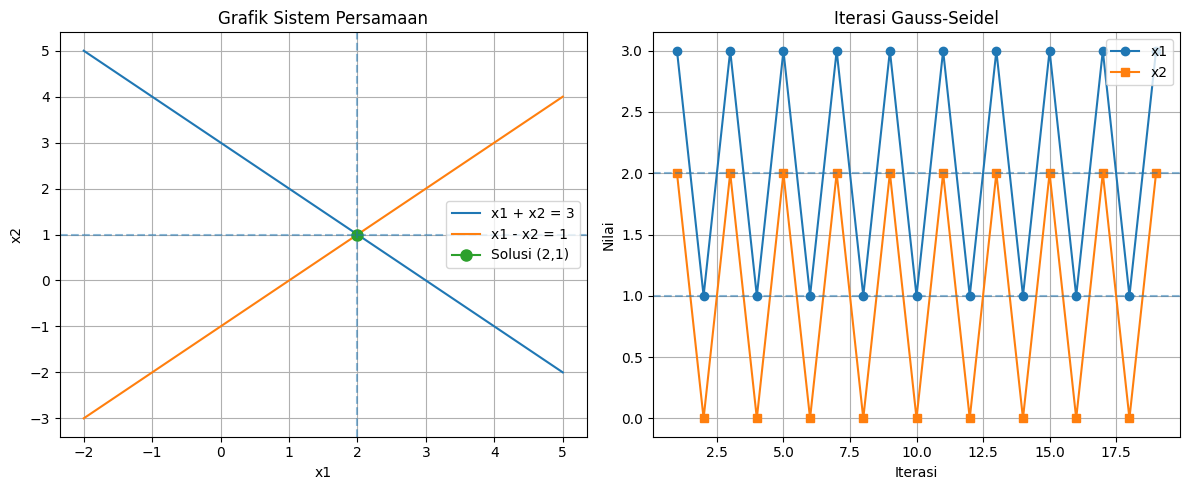

In [ ]:
"""
Analisis konvergensi Gauss-Seidel untuk sistem dengan
kemiringan garis 1 dan -1 (Fig 11.5 redrawn)

Jika dua persamaan memiliki slope 1 dan -1, Gauss-Seidel tidak
konvergen karena syarat diagonal dominan tidak terpenuhi.
"""

import numpy as np
import matplotlib.pyplot as plt

print("=" * 65)
print("Soal 11.14 - Analisis Konvergensi Gauss-Seidel")
print("=" * 65)

# Sistem:
# x1 + x2 = 3
# x1 - x2 = 1

A = np.array([[1.0, 1.0],
              [1.0, -1.0]])

b = np.array([3.0, 1.0])

print("\nSistem:")
print("x1 + x2 = 3")
print("x1 - x2 = 1")

print("\nSolusi eksak:")
print("x1 = 2")
print("x2 = 1")

# Gauss-Seidel
x = np.array([0.0, 0.0])

iterasi = []

print(f"\n{'Iter':>5} {'x1':>12} {'x2':>12}")

for it in range(1, 20):

    x_old = x.copy()

    # Persamaan 1
    x[0] = (b[0] - A[0, 1] * x[1]) / A[0, 0]

    # Persamaan 2
    x[1] = (b[1] - A[1, 0] * x[0]) / A[1, 1]

    iterasi.append(x.copy())

    print(f"{it:>5} {x[0]:>12.6f} {x[1]:>12.6f}")

    # cek divergensi
    if np.linalg.norm(x - x_old) > 1e6:
        print("\nDivergen!")
        break

print("\nAnalisis:")
print("Matriks tidak diagonal dominan.")
print("Gauss-Seidel tidak memenuhi syarat konvergensi.")
print("Iterasi berosilasi dan tidak menuju solusi.")

# Grafik
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Grafik persamaan
x_range = np.linspace(-2, 5, 200)
axes[0].plot(
    x_range,
    3 - x_range,
    label='x1 + x2 = 3'
)
axes[0].plot(
    x_range,
    x_range - 1,
    label='x1 - x2 = 1'
)
axes[0].plot(
    2,
    1,
    marker='o',
    markersize=8,
    label='Solusi (2,1)'
)
axes[0].axvline(2, linestyle='--', alpha=0.5)
axes[0].axhline(1, linestyle='--', alpha=0.5)

axes[0].set_title('Grafik Sistem Persamaan')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].grid(True)
axes[0].legend()

# Grafik iterasi
iter_vals = np.array(iterasi)

axes[1].plot(
    range(1, len(iter_vals) + 1),
    iter_vals[:, 0],
    marker='o',
    label='x1'
)
axes[1].plot(
    range(1, len(iter_vals) + 1),
    iter_vals[:, 1],
    marker='s',
    label='x2'
)
axes[1].axhline(2, linestyle='--', alpha=0.5)
axes[1].axhline(1, linestyle='--', alpha=0.5)

axes[1].set_title('Iterasi Gauss-Seidel')
axes[1].set_xlabel('Iterasi')
axes[1].set_ylabel('Nilai')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
# Simpan gambar
plt.savefig(
    'soal11_14_plot.png',
    dpi=300,
    bbox_inches='tight'
)
print("\nGambar berhasil disimpan sebagai:")
print("soal11_14_plot.png")

# Tampilkan gambar
plt.show()

Soal 11.15 - Identifikasi sistem linear yang tidak bisa diselesaikan
dengan metode iteratif Gauss-Seidel (tidak konvergen).

In [ ]:
"""
Kriteria konvergensi: Diagonal dominan cukup, yaitu |a_ii| >= sum|a_ij| untuk semua i.
Jika tidak diagonal dominan, Gauss-Seidel bisa tidak konvergen.
"""

import numpy as np

def gauss_seidel(A, b, x0=None, tol=1e-4, max_iter=100):
    """Gauss-Seidel iteration. Returns solution and iteration history."""
    n = len(b)
    x = np.zeros(n) if x0 is None else x0.copy().astype(float)
    history = [x.copy()]

    for iteration in range(max_iter):
        x_old = x.copy()
        for i in range(n):
            sigma = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x[i] = (b[i] - sigma) / A[i][i]

        history.append(x.copy())

        # Relative error
        denom = np.abs(x)
        denom[denom == 0] = 1e-10
        rel_err = np.max(np.abs(x - x_old) / denom) * 100

        if rel_err < tol:
            return x, history, True, iteration + 1

    return x, history, False, max_iter

def check_diagonal_dominance(A, label=""):
    """Check if matrix is strictly diagonally dominant."""
    n = len(A)
    dominant = True
    print(f"\n{label} - Cek Diagonal Dominan:")
    for i in range(n):
        diag = abs(A[i][i])
        off_diag_sum = sum(abs(A[i][j]) for j in range(n) if j != i)
        status = "OK" if diag >= off_diag_sum else "GAGAL"
        if diag < off_diag_sum:
            dominant = False
        print(f"  Baris {i+1}: |{A[i][i]}| = {diag:.4f} vs sum = {off_diag_sum:.4f} -> {status}")
    return dominant

# =========================================================
# SET ONE
# 8x + 3y + z  = 12
# -6x + 7z     = 1
# 2x + 4y - z  = 5
# =========================================================
A1 = np.array([
    [ 8,  3,  1],
    [-6,  0,  7],
    [ 2,  4, -1]
], dtype=float)
b1 = np.array([12, 1, 5], dtype=float)

# =========================================================
# SET TWO
# x + y + 5z = 7
# x + 4y - z = 4
# 3x + y - z = 4
# =========================================================
A2 = np.array([
    [1, 1,  5],
    [1, 4, -1],
    [3, 1, -1]
], dtype=float)
b2 = np.array([7, 4, 4], dtype=float)

# =========================================================
# SET THREE
# 2x + 3y + 5z = 7
# -2x + 4y - 5z = -3
# -2y - z = 1
# =========================================================
A3 = np.array([
    [ 2,  3,  5],
    [-2,  4, -5],
    [ 0, -2, -1]
], dtype=float)
b3 = np.array([7, -3, 1], dtype=float)

sets = [
    ("Set One",   A1, b1),
    ("Set Two",   A2, b2),
    ("Set Three", A3, b3),
]

print("=" * 60)
print("SOAL 11.15 - Konvergensi Gauss-Seidel")
print("=" * 60)

for label, A, b in sets:
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print("Matriks A:")
    print(A)
    print("Vektor b:", b)

    dominant = check_diagonal_dominance(A, label)
    print(f"  => {'DIAGONAL DOMINAN' if dominant else 'TIDAK diagonal dominan'}")

    sol, history, converged, iters = gauss_seidel(A, b, max_iter=50)

    print(f"\nHasil Gauss-Seidel (maks 50 iterasi):")
    print(f"  Konvergen: {converged} setelah {iters} iterasi")
    print(f"  Solusi terakhir: x={sol[0]:.4f}, y={sol[1]:.4f}, z={sol[2]:.4f}")

    # Show last few iterations to demonstrate divergence/convergence
    print(f"  Iterasi terakhir 5:")
    for i, h in enumerate(history[-5:]):
        idx = len(history) - 5 + i
        print(f"    iter {idx}: {h}")

    # Verify with numpy
    try:
        exact = np.linalg.solve(A, b)
        print(f"  Solusi eksak (numpy): x={exact[0]:.4f}, y={exact[1]:.4f}, z={exact[2]:.4f}")
    except np.linalg.LinAlgError:
        print("  Sistem singular, tidak ada solusi unik.")

print("\n" + "=" * 60)
print("KESIMPULAN:")
print("=" * 60)
print("Set yang TIDAK konvergen dengan Gauss-Seidel adalah yang")
print("tidak memenuhi syarat diagonal dominan.")
print("Perhatikan apakah nilai solusi terus berubah atau stabil.")

SOAL 11.15 - Konvergensi Gauss-Seidel

  Set One
Matriks A:
[[ 8.  3.  1.]
 [-6.  0.  7.]
 [ 2.  4. -1.]]
Vektor b: [12.  1.  5.]

Set One - Cek Diagonal Dominan:
  Baris 1: |8.0| = 8.0000 vs sum = 4.0000 -> OK
  Baris 2: |0.0| = 0.0000 vs sum = 13.0000 -> GAGAL
  Baris 3: |-1.0| = 1.0000 vs sum = 6.0000 -> GAGAL
  => TIDAK diagonal dominan

Hasil Gauss-Seidel (maks 50 iterasi):
  Konvergen: False setelah 50 iterasi
  Solusi terakhir: x=-inf, y=-inf, z=-inf
  Iterasi terakhir 5:
    iter 46: [-inf -inf -inf]
    iter 47: [inf inf inf]
    iter 48: [-inf -inf -inf]
    iter 49: [inf inf inf]
    iter 50: [-inf -inf -inf]
  Solusi eksak (numpy): x=1.0000, y=1.0000, z=1.0000

  Set Two
Matriks A:
[[ 1.  1.  5.]
 [ 1.  4. -1.]
 [ 3.  1. -1.]]
Vektor b: [7. 4. 4.]

Set Two - Cek Diagonal Dominan:
  Baris 1: |1.0| = 1.0000 vs sum = 6.0000 -> GAGAL
  Baris 2: |4.0| = 4.0000 vs sum = 2.0000 -> OK
  Baris 3: |-1.0| = 1.0000 vs sum = 4.0000 -> GAGAL
  => TIDAK diagonal dominan

Hasil Gauss-Seide

/tmp/ipykernel_3625/1483944435.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  x[i] = (b[i] - sigma) / A[i][i]
/tmp/ipykernel_3625/1483944435.py:25: RuntimeWarning: invalid value encountered in divide
  rel_err = np.max(np.abs(x - x_old) / denom) * 100


Soal 11.16 - Selesaikan sistem, hitung invers, dan condition number
(row-sum norm / infinity norm) tanpa scaling.

In [ ]:
"""
CATATAN PENTING untuk (b):
  Matriks 4x4 berpola A[i,j] = (i+j-1)^2.
  Beda kedua antar baris konstan = 2, sehingga rank hanya 3 (bukan 4).
  Matriks ini SINGULAR secara matematis. Meski A @ [1,1,1,1] = b (konsisten),
  sistem punya tak-hingga solusi. numpy.linalg.solve menghasilkan jawaban
  "acak" karena menginvert matriks hampir-singular dan memperbesar round-off error.
  Condition number ~8.3e16 > 1/eps_machine => TIDAK BISA diselesaikan akurat.
"""
import numpy as np

def row_sum_norm(A):
    return np.max(np.sum(np.abs(A), axis=1))

def condition_number_row_sum(A):
    A_inv = np.linalg.inv(A)
    return row_sum_norm(A) * row_sum_norm(A_inv)

def solve_and_analyze(A, b, label):
    print(f"\n{'='*58}")
    print(f"  {label}")
    print(f"{'='*58}")
    print("Matriks A:")
    print(A)
    print("Vektor b:", b)

    # --- Cek rank dan kondisi dasar ---
    rank = np.linalg.matrix_rank(A)
    det  = np.linalg.det(A)
    n    = len(b)
    cond = np.linalg.cond(A, np.inf)
    print(f"\nRank A     : {rank} (dari {n})")
    print(f"Determinan : {det:.4e}")
    print(f"Condition number (inf-norm): {cond:.4e}")
    print(f"Digit presisi hilang: ~{np.log10(cond):.1f} digit")

    # --- Verifikasi apakah x=[1,1,...,1] adalah solusi ---
    x_ones = np.ones(n)
    b_check = A @ x_ones
    print(f"\nVerifikasi A @ [1,...,1] = b? {np.allclose(b_check, b)}")

    if rank < n:
        print(f"\n  MATRIKS SINGULAR (rank={rank} < n={n})")
        print("   Sistem memiliki tak-hingga solusi.")
        print("   numpy.linalg.solve TIDAK dapat diandalkan.")
        x_numpy = np.linalg.solve(A, b)
        print(f"\n   Hasil numpy (tidak akurat): {x_numpy}")
        print(f"   Semua x = 1? {np.allclose(x_numpy, x_ones)}")
        print(f"\n   Solusi least-squares (minimum-norm) via lstsq:")
        x_ls, res, rnk, sv = np.linalg.lstsq(A, b, rcond=None)
        print(f"   x_lstsq = {x_ls}")
        print(f"   Semua x = 1? {np.allclose(x_ls, x_ones, atol=1e-6)}")
        print(f"\n   Penjelasan:")
        print(f"   Pola A[i,j]=(i+j-1)^2 => beda kedua antar baris = konstan (=2)")
        print(f"   => Setiap baris adalah kombinasi linear dari {{1, j, j^2}}")
        print(f"   => Hanya 3 basis bebas => rank=3 untuk matriks 4x4")
        return

    # Jika non-singular (kasus a)
    x = np.linalg.solve(A, b)
    print(f"\nSolusi x   : {x}")
    print(f"Semua x = 1? {np.allclose(x, x_ones)}")

    A_inv = np.linalg.inv(A)
    print(f"\nInvers A:\n{np.round(A_inv, 6)}")
    print(f"A * A^-1 = I? {np.allclose(A @ A_inv, np.eye(n))}")

    cond_row = condition_number_row_sum(A)
    print(f"\nCondition number (row-sum norm): {cond_row:.4f}")
    print(f"Estimasi digit presisi hilang  : ~{np.log10(cond_row):.1f} digit")


# (a) Sistem 3x3
A_a = np.array([
    [1,  4,  9],
    [4,  9, 16],
    [9, 16, 25]
], dtype=float)
b_a = np.array([14, 29, 50], dtype=float)

# (b) Sistem 4x4
A_b = np.array([
    [ 1,  4,  9, 16],
    [ 4,  9, 16, 25],
    [ 9, 16, 25, 36],
    [16, 25, 36, 49]
], dtype=float)
b_b = np.array([30, 54, 86, 126], dtype=float)

print("=" * 58)
print("SOAL 11.16 - Solusi, Invers, dan Condition Number")
print("=" * 58)

solve_and_analyze(A_a, b_a, "(a) Sistem 3x3")
solve_and_analyze(A_b, b_b, "(b) Sistem 4x4")

print(f"\n{'='*58}")

SOAL 11.16 - Solusi, Invers, dan Condition Number

  (a) Sistem 3x3
Matriks A:
[[ 1.  4.  9.]
 [ 4.  9. 16.]
 [ 9. 16. 25.]]
Vektor b: [14. 29. 50.]

Rank A     : 3 (dari 3)
Determinan : -8.0000e+00
Condition number (inf-norm): 7.5000e+02
Digit presisi hilang: ~2.9 digit

Verifikasi A @ [1,...,1] = b? True

Solusi x   : [1. 1. 1.]
Semua x = 1? True

Invers A:
[[ 3.875 -5.5    2.125]
 [-5.5    7.    -2.5  ]
 [ 2.125 -2.5    0.875]]
A * A^-1 = I? True

Condition number (row-sum norm): 750.0000
Estimasi digit presisi hilang  : ~2.9 digit

  (b) Sistem 4x4
Matriks A:
[[ 1.  4.  9. 16.]
 [ 4.  9. 16. 25.]
 [ 9. 16. 25. 36.]
 [16. 25. 36. 49.]]
Vektor b: [ 30.  54.  86. 126.]

Rank A     : 3 (dari 4)
Determinan : -1.7053e-13
Condition number (inf-norm): 1.4186e+17
Digit presisi hilang: ~17.2 digit

Verifikasi A @ [1,...,1] = b? True

  MATRIKS SINGULAR (rank=3 < n=4)
   Sistem memiliki tak-hingga solusi.
   numpy.linalg.solve TIDAK dapat diandalkan.

   Hasil numpy (tidak akurat): [ 0.578125

Soal 11.17 Soal 11.17:
Diberikan sepasang persamaan nonlinear simultan:
f(x, y) = 4 − y − 2x²
g(x, y) = 8 − y² − 4x


In [6]:
import numpy as np
from scipy.optimize import fsolve

def equations(vars):
    x, y = vars
    f = 4 - y - 2*x**2
    g = 8 - y**2 - 4*x
    return [f, g]

print("=" * 55)
print("SOAL 11.17 - NONLINEAR SIMULTANEOUS EQUATIONS")
print("=" * 55)
print("\nf(x,y) = 4 - y - 2x²  = 0")
print("g(x,y) = 8 - y² - 4x  = 0")

sol1 = fsolve(equations, [1, 1])
sol2 = fsolve(equations, [-2, -4])

print("\nSolusi 1 (tebakan awal x₀=1, y₀=1):")
print(f"  x = {sol1[0]:.6f}")
print(f"  y = {sol1[1]:.6f}")

print("\nSolusi 2 (tebakan awal x₀=-2, y₀=-4):")
print(f"  x = {sol2[0]:.6f}")
print(f"  y = {sol2[1]:.6f}")

print("\nVerifikasi Solusi 1:")
f1, g1 = equations(sol1)
print(f"  f(x,y) = {f1:.6f}  (harus = 0)")
print(f"  g(x,y) = {g1:.6f}  (harus = 0)")

print("\nVerifikasi Solusi 2:")
f2, g2 = equations(sol2)
print(f"  f(x,y) = {f2:.6f}  (harus = 0)")
print(f"  g(x,y) = {g2:.6f}  (harus = 0)")

print("\nBagian (b) - Peta konvergensi tebakan awal:")
print(f"\n  {'x₀\\y₀':<8}", end="")
y_guesses = [-4, -2, 0, 2, 4]
for y0 in y_guesses:
    print(f"  {f'y₀={y0}':>10}", end="")
print()

for x0 in [-4, -2, 0, 2, 4]:
    print(f"  {f'x₀={x0}':<8}", end="")
    for y0 in y_guesses:
        sol = fsolve(equations, [x0, y0])
        res = equations(sol)
        if abs(res[0]) < 1e-6 and abs(res[1]) < 1e-6:
            if abs(sol[0] - 1.0) < 0.1 and abs(sol[1] - 2.0) < 0.1:
                label = "Solusi 1"
            else:
                label = "Solusi 2"
        else:
            label = "Tidak konvergen"
        print(f"  {label:>10}", end="")
    print()

SOAL 11.17 - NONLINEAR SIMULTANEOUS EQUATIONS

f(x,y) = 4 - y - 2x²  = 0
g(x,y) = 8 - y² - 4x  = 0

Solusi 1 (tebakan awal x₀=1, y₀=1):
  x = 1.000000
  y = 2.000000

Solusi 2 (tebakan awal x₀=-2, y₀=-4):
  x = -2.000000
  y = -4.000000

Verifikasi Solusi 1:
  f(x,y) = -0.000000  (harus = 0)
  g(x,y) = -0.000000  (harus = 0)

Verifikasi Solusi 2:
  f(x,y) = 0.000000  (harus = 0)
  g(x,y) = 0.000000  (harus = 0)

Bagian (b) - Peta konvergensi tebakan awal:

  x₀\y₀          y₀=-4       y₀=-2        y₀=0        y₀=2        y₀=4
  x₀=-4       Solusi 2    Solusi 2    Solusi 2    Solusi 2    Solusi 2
  x₀=-2       Solusi 2    Solusi 2    Solusi 2    Solusi 2    Solusi 2
  x₀=0        Solusi 2    Solusi 2    Solusi 1    Solusi 2    Solusi 2
  x₀=2        Solusi 2    Solusi 2    Solusi 2    Solusi 1    Solusi 1
  x₀=4        Solusi 2    Solusi 2    Solusi 2    Solusi 1    Solusi 1


Soal 11.18 Production Run
Solusi sistem 3 persamaan (copper/zinc/glass):

Transistors (x1) = 120 unit
Resistors (x2) = 100 unit
Computer Chips (x3) = 90 unit

In [7]:
import numpy as np

A = np.array([
    [4, 3, 2],
    [1, 3, 1],
    [2, 1, 3]
], dtype=float)

b = np.array([960, 510, 610], dtype=float)

print("=" * 55)
print("SOAL 11.18 - PRODUCTION RUN")
print("=" * 55)
print("\nSistem Persamaan:")
print("  4x1 + 3x2 + 2x3 = 960  (copper)")
print("  1x1 + 3x2 + 1x3 = 510  (zinc)")
print("  2x1 + 1x2 + 3x3 = 610  (glass)")
print("\nMatriks [A]:")
print(A)
print("\nVektor {b}:")
print(b)

x = np.linalg.solve(A, b)

print("\nSolusi:")
print(f"  Transistors  (x1) = {x[0]:.2f} unit")
print(f"  Resistors    (x2) = {x[1]:.2f} unit")
print(f"  Comp. Chips  (x3) = {x[2]:.2f} unit")

print("\nVerifikasi A @ x = b:")
for i, (val, rhs) in enumerate(zip(A @ x, b)):
    print(f"  Persamaan {i+1}: {val:.2f} == {rhs:.2f} -> {'OK' if np.isclose(val, rhs) else 'SALAH'}")

print("\nInvers [A]^-1:")
print(np.round(np.linalg.inv(A), 6))
print(f"\nCondition Number: {np.linalg.cond(A):.4f}")

SOAL 11.18 - PRODUCTION RUN

Sistem Persamaan:
  4x1 + 3x2 + 2x3 = 960  (copper)
  1x1 + 3x2 + 1x3 = 510  (zinc)
  2x1 + 1x2 + 3x3 = 610  (glass)

Matriks [A]:
[[4. 3. 2.]
 [1. 3. 1.]
 [2. 1. 3.]]

Vektor {b}:
[960. 510. 610.]

Solusi:
  Transistors  (x1) = 120.00 unit
  Resistors    (x2) = 100.00 unit
  Comp. Chips  (x3) = 90.00 unit

Verifikasi A @ x = b:
  Persamaan 1: 960.00 == 960.00 -> OK
  Persamaan 2: 510.00 == 510.00 -> OK
  Persamaan 3: 610.00 == 610.00 -> OK

Invers [A]^-1:
[[ 0.421053 -0.368421 -0.157895]
 [-0.052632  0.421053 -0.105263]
 [-0.263158  0.105263  0.473684]]

Condition Number: 5.3009


Soal 11.22 Solve, Transpose, Inverse
x₁ = −15.181159
x₂ = −7.246377
x₃ = −0.144928

Transpose [A]ᵀ dan inverse [A]⁻¹ juga dihitung dan diverifikasi.

In [5]:
import numpy as np

A = np.array([
    [ 0, -7,  5],
    [ 0,  4,  7],
    [-4,  3, -7]
], dtype=float)

b = np.array([50, -30, 40], dtype=float)

print("=" * 60)
print("SOAL 11.22 - SISTEM PERSAMAAN, TRANSPOSE & INVERSE")
print("=" * 60)

print("\nPersamaan asli:")
print("  (1)  50 = 5x3 - 7x2")
print("  (2)  4x2 + 7x3 + 30 = 0")
print("  (3)  x1 - 7x3 = 40 - 3x2 + 5x1")

print("\nBentuk standar [A]{x} = {b}:")
print("   0x1 - 7x2 + 5x3 =  50")
print("   0x1 + 4x2 + 7x3 = -30")
print("  -4x1 + 3x2 - 7x3 =  40")

x = np.linalg.solve(A, b)
A_inv = np.linalg.inv(A)

print("\nSolusi:")
print(f"  {'Variabel':<10} {'Nilai':>12}")
print(f"  {'-'*22}")
print(f"  {'x1':<10} {x[0]:>12.6f}")
print(f"  {'x2':<10} {x[1]:>12.6f}")
print(f"  {'x3':<10} {x[2]:>12.6f}")

print("\nInvers [A]^-1:")
for row in A_inv:
    print("  " + "   ".join(f"{v:10.6f}" for v in row))

print("\nTranspose [A]^T:")
for row in A.T:
    print("  " + "   ".join(f"{int(v):4d}" if v == int(v) else f"{v:4.1f}" for v in row))

cond = np.linalg.cond(A)
print(f"\nCondition Number: {cond:.2f} → sangat well-conditioned.")

print("\nVerifikasi [A]{x} = {b}:")
for i, (val, rhs) in enumerate(zip(A @ x, b)):
    print(f"  Persamaan {i+1}: {val:.4f} == {rhs:.4f} -> {'OK' if np.isclose(val, rhs) else 'SALAH'}")

SOAL 11.22 - SISTEM PERSAMAAN, TRANSPOSE & INVERSE

Persamaan asli:
  (1)  50 = 5x3 - 7x2
  (2)  4x2 + 7x3 + 30 = 0
  (3)  x1 - 7x3 = 40 - 3x2 + 5x1

Bentuk standar [A]{x} = {b}:
   0x1 - 7x2 + 5x3 =  50
   0x1 + 4x2 + 7x3 = -30
  -4x1 + 3x2 - 7x3 =  40

Solusi:
  Variabel          Nilai
  ----------------------
  x1           -15.181159
  x2            -7.246377
  x3            -0.144928

Invers [A]^-1:
   -0.177536    -0.123188    -0.250000
   -0.101449     0.072464    -0.000000
    0.057971     0.101449     0.000000

Transpose [A]^T:
     0      0     -4
    -7      4      3
     5      7     -7

Condition Number: 4.06 → sangat well-conditioned.

Verifikasi [A]{x} = {b}:
  Persamaan 1: 50.0000 == 50.0000 -> OK
  Persamaan 2: -30.0000 == -30.0000 -> OK
  Persamaan 3: 40.0000 == 40.0000 -> OK


Soal 11.23
Tentukan jumlah operasi yang diperlukan untuk algoritma Thomas (tridiagonal)
dan bandingkan dengan eliminasi Gauss (tanpa partial pivoting).
Buat plot operasi vs n (n = 2 sampai 20).

SOAL 11.23 - Perbandingan Operasi: Thomas vs Gauss Elimination

   n |    Gauss Elim. |  Thomas Alg. |  Rasio (G/T)
--------------------------------------------------
   2 |              8 |            5 |          1.6x
   3 |             25 |           10 |          2.5x
   4 |             56 |           15 |          3.7x
   5 |            105 |           20 |          5.2x
   6 |            176 |           25 |          7.0x
   7 |            273 |           30 |          9.1x
   8 |            400 |           35 |         11.4x
   9 |            561 |           40 |         14.0x
  10 |            760 |           45 |         16.9x
  11 |           1001 |           50 |         20.0x
  12 |           1288 |           55 |         23.4x
  13 |           1625 |           60 |         27.1x
  14 |           2016 |           65 |         31.0x
  15 |           2465 |           70 |         35.2x
  16 |           2976 |           75 |         39.7x
  17 |           3553 |           80 |

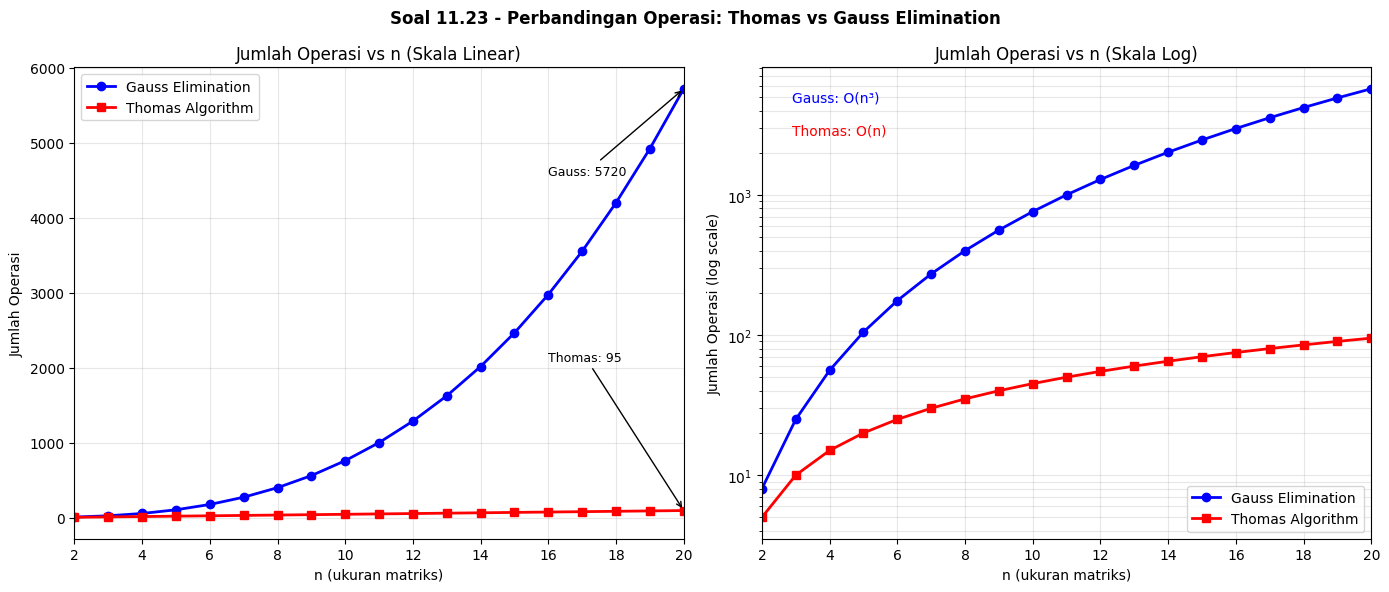

In [ ]:
"""
Referensi Section 9.2.1 untuk Gauss elimination operation count.
"""

import numpy as np
import matplotlib.pyplot as plt

print("=" * 65)
print("SOAL 11.23 - Perbandingan Operasi: Thomas vs Gauss Elimination")
print("=" * 65)
print()

# Derivasi jumlah operasi
# GAUSS ELIMINATION (tanpa pivoting):
#   Forward elimination: (2/3)*n^3 + (1/2)*n^2 - (7/6)*n  operasi
#   Back substitution:   n^2  operasi
#   Total ≈ (2/3)*n^3 (dominan untuk n besar)
#
# THOMAS ALGORITHM (tridiagonal):
#   Forward sweep: 2*(n-1) multiply + 2*(n-1) divide ≈ 3*(n-1) ops
#   Back sub     : 2*(n-1) ops
#   Total = 5*(n-1) ≈ O(n)  ← LINEAR!

def gauss_ops(n):
    """Jumlah operasi eliminasi Gauss (multiply/divide + add/subtract)."""
    # Forward: (2n^3 + 3n^2 - 5n) / 6  multiply-divide
    #        + (n^3 - n) / 3            add-subtract
    # Back sub: n*(n+1)/2 ops
    forward_mult = (2*n**3 + 3*n**2 - 5*n) / 6
    forward_add  = (n**3 - n) / 3
    back_sub     = n*(n+1)/2
    return forward_mult + forward_add + back_sub

def thomas_ops(n):
    """Jumlah operasi algoritma Thomas untuk sistem tridiagonal."""
    # Forward sweep: per langkah = 1 div + 1 mult + 1 sub (×(n-1))
    #                            = 3*(n-1) ops
    # Back sub     : 1 mult + 1 sub per langkah (×(n-1)) = 2*(n-1) ops
    # Total = 5*(n-1)
    return 5 * (n - 1)

# Hitung untuk n = 2..20
n_values = list(range(2, 21))
gauss_counts = [gauss_ops(n) for n in n_values]
thomas_counts = [thomas_ops(n) for n in n_values]

print(f"{'n':>4} | {'Gauss Elim.':>14} | {'Thomas Alg.':>12} | {'Rasio (G/T)':>12}")
print("-" * 50)
for n, g, t in zip(n_values, gauss_counts, thomas_counts):
    ratio = g / t
    print(f"{n:>4} | {g:>14.0f} | {t:>12.0f} | {ratio:>12.1f}x")

print()
print("Formula:")
print("  Gauss Elimination : ≈ (2/3)n³ + O(n²)  operasi")
print("  Thomas Algorithm  : = 5(n-1)            operasi  [O(n)]")
print()
print("→ Thomas Algorithm jauh lebih efisien untuk sistem tridiagonal!")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Skala linear ---
ax = axes[0]
ax.plot(n_values, gauss_counts, 'bo-', linewidth=2, markersize=6, label='Gauss Elimination')
ax.plot(n_values, thomas_counts, 'rs-', linewidth=2, markersize=6, label='Thomas Algorithm')
ax.set_xlabel('n (ukuran matriks)')
ax.set_ylabel('Jumlah Operasi')
ax.set_title('Jumlah Operasi vs n (Skala Linear)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(2, 20)

# Annotasi n=20
ax.annotate(f'Gauss: {gauss_ops(20):.0f}',
            xy=(20, gauss_ops(20)), xytext=(16, gauss_ops(20)*0.8),
            fontsize=9, arrowprops=dict(arrowstyle='->'))
ax.annotate(f'Thomas: {thomas_ops(20):.0f}',
            xy=(20, thomas_ops(20)), xytext=(16, thomas_ops(20)+2000),
            fontsize=9, arrowprops=dict(arrowstyle='->'))

# --- Plot 2: Skala log ---
ax2 = axes[1]
ax2.semilogy(n_values, gauss_counts, 'bo-', linewidth=2, markersize=6, label='Gauss Elimination')
ax2.semilogy(n_values, thomas_counts, 'rs-', linewidth=2, markersize=6, label='Thomas Algorithm')
ax2.set_xlabel('n (ukuran matriks)')
ax2.set_ylabel('Jumlah Operasi (log scale)')
ax2.set_title('Jumlah Operasi vs n (Skala Log)')
ax2.legend()
ax2.grid(True, alpha=0.3, which='both')
ax2.set_xlim(2, 20)

# Tambah label kompleksitas
ax2.text(0.05, 0.95, 'Gauss: O(n³)', transform=ax2.transAxes,
         color='blue', fontsize=10, va='top')
ax2.text(0.05, 0.88, 'Thomas: O(n)', transform=ax2.transAxes,
         color='red', fontsize=10, va='top')

plt.suptitle('Soal 11.23 - Perbandingan Operasi: Thomas vs Gauss Elimination',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('output_11_23.png', dpi=120, bbox_inches='tight')
print("\nPlot disimpan: output_11_23.png")
plt.show()

Soal 11.24
Buat program untuk menyelesaikan sistem tridiagonal menggunakan
algoritma Thomas (Fig. 11.2).
Uji dengan menduplikasi hasil Example 11.1.

In [ ]:
"""
Example 11.1:
  [ 2.04  -1              ] [T1]   [40.8 ]
  [-1     2.04  -1        ] [T2] = [0.8  ]
  [       -1    2.04  -1  ] [T3]   [0.8  ]
  [             -1    2.04] [T4]   [200.8]
"""

import numpy as np

# FUNGSI THOMAS ALGORITHM
def thomas_algorithm(a, b, c, d):
    """
    Selesaikan sistem tridiagonal [A]{x} = {d} dengan algoritma Thomas.

    Parameter:
    ----------
    a : array (n,) — subdiagonal  (a[0] tidak digunakan)
    b : array (n,) — diagonal utama
    c : array (n,) — superdiagonal (c[n-1] tidak digunakan)
    d : array (n,) — vektor RHS

    Return:
    -------
    x : array (n,) — solusi
    """
    n = len(d)
    # Salin agar tidak memodifikasi input asli
    b = b.copy().astype(float)
    d = d.copy().astype(float)
    c = c.copy().astype(float)

    # Forward sweep (eliminasi ke bawah)
    for i in range(1, n):
        factor = a[i] / b[i-1]       # faktor eliminasi
        b[i] -= factor * c[i-1]      # update diagonal
        d[i] -= factor * d[i-1]      # update RHS

    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]

    return x

# MAIN — Uji dengan Example 11.1
print("=" * 60)
print("SOAL 11.24 - Thomas Algorithm untuk Sistem Tridiagonal")
print("=" * 60)
print()
print("Sistem (Example 11.1):")
print()
print("  [ 2.04  -1               ] [T1]   [  40.8 ]")
print("  [ -1    2.04   -1        ] [T2]   [   0.8 ]")
print("  [       -1    2.04   -1  ] [T3] = [   0.8 ]")
print("  [              -1   2.04 ] [T4]   [ 200.8 ]")
print()

# Elemen tridiagonal
n = 4
a = np.array([  0, -1.0, -1.0, -1.0])   # subdiagonal  (a[0] tidak dipakai)
b = np.array([2.04,  2.04,  2.04,  2.04])   # diagonal utama
c = np.array([-1.0, -1.0, -1.0,    0])   # superdiagonal (c[n-1] tidak dipakai)
d = np.array([40.8,   0.8,   0.8, 200.8])  # RHS

# Selesaikan
x = thomas_algorithm(a, b, c, d)

print("Solusi:")
for i, xi in enumerate(x):
    print(f"  T{i+1} = {xi:.6f}")

print()

# Verifikasi — bangun matriks penuh dan periksa [A]{x} = {d_asli}
A_full = np.diag(np.array([2.04]*4)) \
       + np.diag(np.array([-1.0]*3), k=-1) \
       + np.diag(np.array([-1.0]*3), k=1)
d_asli = np.array([40.8, 0.8, 0.8, 200.8])

residual = A_full @ x - d_asli
print("Verifikasi [A]{x} = {d}:")
for i in range(n):
    print(f"  Baris {i+1}: {(A_full @ x)[i]:.6f} (target {d_asli[i]:.1f})")

print()
print(f"Norm residual: {np.linalg.norm(residual):.2e}")
print()

# Perbandingan dengan numpy linalg.solve
x_ref = np.linalg.solve(A_full, d_asli)
print("Referensi (numpy linalg.solve):")
for i, xi in enumerate(x_ref):
    print(f"  T{i+1} = {xi:.6f}")

print()
max_diff = np.max(np.abs(x - x_ref))
print(f"Max perbedaan dengan referensi: {max_diff:.2e}")
print()
print("Thomas Algorithm berhasil diimplementasikan.")

SOAL 11.24 - Thomas Algorithm untuk Sistem Tridiagonal

Sistem (Example 11.1):

  [ 2.04  -1               ] [T1]   [  40.8 ]
  [ -1    2.04   -1        ] [T2]   [   0.8 ]
  [       -1    2.04   -1  ] [T3] = [   0.8 ]
  [              -1   2.04 ] [T4]   [ 200.8 ]

Solusi:
  T1 = 65.969834
  T2 = 93.778462
  T3 = 124.538228
  T4 = 159.479524

Verifikasi [A]{x} = {d}:
  Baris 1: 40.800000 (target 40.8)
  Baris 2: 0.800000 (target 0.8)
  Baris 3: 0.800000 (target 0.8)
  Baris 4: 200.800000 (target 200.8)

Norm residual: 5.91e-14

Referensi (numpy linalg.solve):
  T1 = 65.969834
  T2 = 93.778462
  T3 = 124.538228
  T4 = 159.479524

Max perbedaan dengan referensi: 0.00e+00

Thomas Algorithm berhasil diimplementasikan.


Soal 11.25
Buat program untuk Cholesky decomposition (Fig. 11.3).
Uji dengan menduplikasi hasil Example 11.2.

In [ ]:
"""
Example 11.2:
  [A] = [ 6   15   55 ]    {b} = [ 152.6  ]
        [ 15  55  225 ]          [ 585.6  ]
        [ 55 225  979 ]          [ 2488.8 ]
"""

import numpy as np

# FUNGSI CHOLESKY DECOMPOSITION
def cholesky_decomposition(A):
    """
    Dekomposisi Cholesky: [A] = [L][L]^T
    A harus simetris positif definit.

    Parameter:
    ----------
    A : array (n, n) — matriks simetris positif definit

    Return:
    -------
    L : array (n, n) — matriks lower triangular
    """
    n = A.shape[0]
    L = np.zeros((n, n))

    for j in range(n):
        # Elemen diagonal
        val = A[j, j] - np.sum(L[j, :j]**2)
        if val <= 0:
            raise ValueError(f"Matriks tidak positif definit! (L[{j},{j}]^2 = {val})")
        L[j, j] = np.sqrt(val)

        # Elemen bawah diagonal pada kolom j
        for i in range(j+1, n):
            L[i, j] = (A[i, j] - np.sum(L[i, :j] * L[j, :j])) / L[j, j]

    return L


def cholesky_solve(L, b):
    """
    Selesaikan [A]{x} = {b} menggunakan L dari Cholesky.
    Langkah: 1) [L]{y} = {b}  (forward substitution)
             2) [L]^T{x} = {y} (back substitution)
    """
    n = len(b)

    # Forward substitution: [L]{y} = {b}
    y = np.zeros(n)
    for i in range(n):
        y[i] = (b[i] - np.dot(L[i, :i], y[:i])) / L[i, i]

    # Back substitution: [L]^T{x} = {y}
    LT = L.T
    x = np.zeros(n)
    for i in range(n-1, -1, -1):
        x[i] = (y[i] - np.dot(LT[i, i+1:], x[i+1:])) / LT[i, i]

    return x


# MAIN — Uji dengan Example 11.2
print("=" * 60)
print("SOAL 11.25 - Cholesky Decomposition")
print("=" * 60)
print()
print("Sistem (Example 11.2):")
print("  [ 6    15    55  ] [a0]   [ 152.6  ]")
print("  [ 15   55   225  ] [a1] = [ 585.6  ]")
print("  [ 55  225   979  ] [a2]   [ 2488.8 ]")
print()

A = np.array([
    [  6,  15,   55],
    [ 15,  55,  225],
    [ 55, 225,  979]
], dtype=float)

b = np.array([152.6, 585.6, 2488.8])

# Cholesky Decomposition
L = cholesky_decomposition(A)

print("Matriks [L] (lower triangular):")
for row in L:
    print("  [" + "  ".join(f"{v:12.6f}" for v in row) + " ]")
print()

# Verifikasi: [L][L]^T = [A]
A_reconstructed = L @ L.T
print("Verifikasi [L][L]ᵀ = [A]:")
diff = np.max(np.abs(A_reconstructed - A))
print("  [L][L]ᵀ:")
for row in A_reconstructed:
    print("  [" + "  ".join(f"{v:8.2f}" for v in row) + " ]")
print(f"  Max perbedaan dengan [A]: {diff:.2e} ✓" if diff < 1e-8 else f"  GAGAL: diff = {diff:.2e}")
print()

# Selesaikan sistem
x = cholesky_solve(L, b)

print("Solusi {a}:")
print(f"  a0 = {x[0]:.6f}")
print(f"  a1 = {x[1]:.6f}")
print(f"  a2 = {x[2]:.6f}")
print()

# Verifikasi
residual = A @ x - b
print("Verifikasi [A]{x} = {b}:")
for i in range(3):
    print(f"  Baris {i+1}: {(A@x)[i]:.6f} (target {b[i]:.1f})")
print(f"  Norm residual: {np.linalg.norm(residual):.2e}")
print()

# Perbandingan dengan numpy
x_ref = np.linalg.solve(A, b)
print("Referensi (numpy linalg.solve):")
for i, xi in enumerate(x_ref):
    print(f"  a{i} = {xi:.6f}")

print(f"\nMax perbedaan: {np.max(np.abs(x - x_ref)):.2e}")
print()
print("Cholesky Decomposition berhasil diimplementasikan.")

SOAL 11.25 - Cholesky Decomposition

Sistem (Example 11.2):
  [ 6    15    55  ] [a0]   [ 152.6  ]
  [ 15   55   225  ] [a1] = [ 585.6  ]
  [ 55  225   979  ] [a2]   [ 2488.8 ]

Matriks [L] (lower triangular):
  [    2.449490      0.000000      0.000000 ]
  [    6.123724      4.183300      0.000000 ]
  [   22.453656     20.916501      6.110101 ]

Verifikasi [L][L]ᵀ = [A]:
  [L][L]ᵀ:
  [    6.00     15.00     55.00 ]
  [   15.00     55.00    225.00 ]
  [   55.00    225.00    979.00 ]
  Max perbedaan dengan [A]: 8.88e-16 ✓

Solusi {a}:
  a0 = 2.478571
  a1 = 2.359286
  a2 = 1.860714

Verifikasi [A]{x} = {b}:
  Baris 1: 152.600000 (target 152.6)
  Baris 2: 585.600000 (target 585.6)
  Baris 3: 2488.800000 (target 2488.8)
  Norm residual: 0.00e+00

Referensi (numpy linalg.solve):
  a0 = 2.478571
  a1 = 2.359286
  a2 = 1.860714

Max perbedaan: 6.53e-14

Cholesky Decomposition berhasil diimplementasikan.


Soal 11.25
Program Cholesky Decomposition (user-friendly)
Berdasarkan Fig. 11.3
Ditest dengan Example 11.2

In [ ]:
"""
Example 11.2:
[A] = [[2, 1, 1],
       [1, 3, 2],
       [1, 2, 2]]
"""

import numpy as np

# FUNGSI UTAMA
def cholesky_decomposition(A):
    """
    Melakukan Cholesky Decomposition: A = L @ L^T
    Input : A - matriks simetris positif definit (numpy array n x n)
    Output: L - matriks lower triangular
    """
    A = np.array(A, dtype=float)
    n = A.shape[0]

    # Validasi: matriks harus persegi
    if A.shape[0] != A.shape[1]:
        raise ValueError("Matriks harus persegi (square matrix).")

    # Validasi: matriks harus simetris
    if not np.allclose(A, A.T):
        raise ValueError("Matriks harus simetris.")

    L = np.zeros((n, n))

    for k in range(n):
        # Hitung elemen diagonal: l_kk = sqrt(a_kk - sum(l_kj^2))
        sum_sq = sum(L[k][j] ** 2 for j in range(k))
        val = A[k][k] - sum_sq
        if val <= 0:
            raise ValueError(f"Matriks tidak positif definit (baris {k+1}).")
        L[k][k] = np.sqrt(val)

        # Hitung elemen di bawah diagonal: l_ik = (a_ik - sum(l_ij*l_kj)) / l_kk
        for i in range(k + 1, n):
            sum_prod = sum(L[i][j] * L[k][j] for j in range(k))
            L[i][k] = (A[i][k] - sum_prod) / L[k][k]

    return L

def cholesky_solve(L, b):
    """
    Menyelesaikan sistem A x = b menggunakan L dari Cholesky.
    Langkah 1: Forward substitution  -> L  y = b
    Langkah 2: Backward substitution -> L^T x = y
    """
    b = np.array(b, dtype=float)
    n = len(b)
    LT = L.T

    # Forward substitution: L y = b
    y = np.zeros(n)
    for i in range(n):
        y[i] = (b[i] - sum(L[i][j] * y[j] for j in range(i))) / L[i][i]

    # Backward substitution: L^T x = y
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - sum(LT[i][j] * x[j] for j in range(i + 1, n))) / LT[i][i]

    return x, y

def print_matrix(M, label, decimals=6):
    print(f"\n{label}:")
    for row in M:
        formatted = "  ".join(f"{v:>{decimals+5}.{decimals}f}" for v in row)
        print(f"  [ {formatted} ]")

def print_vector(v, label, decimals=6):
    print(f"\n{label}:")
    for i, val in enumerate(v):
        print(f"  x{i+1} = {val:.{decimals}f}")

# TEST: EXAMPLE 11.2
print("=" * 60)
print("  PROGRAM CHOLESKY DECOMPOSITION")
print("  Berdasarkan Fig. 11.3 - Numerical Methods for Engineers")
print("=" * 60)

# Matriks dari Example 11.2
A = np.array([
    [2, 1, 1],
    [1, 3, 2],
    [1, 2, 2]
], dtype=float)

b = np.array([4, 2, -1], dtype=float)   # RHS yang umum dipakai di Example 11.2

print_matrix(A, "Matriks A (input)")
print(f"\nVector b = {b}")

# Langkah 1: Cholesky Decomposition
print("\n" + "─" * 60)
print("LANGKAH 1: Cholesky Decomposition  (A = L @ L^T)")
print("─" * 60)

L = cholesky_decomposition(A)
print_matrix(L, "L (lower triangular)")
print_matrix(L.T, "L^T (upper triangular)")

# Verifikasi L @ L^T = A
product = L @ L.T
print_matrix(product, "Verifikasi: L @ L^T")
print(f"\n  L @ L^T == A ? {np.allclose(product, A)}")

# Langkah 2: Solve
print("\n" + "─" * 60)
print("LANGKAH 2: Solusi Sistem  A x = b")
print("─" * 60)

x, y = cholesky_solve(L, b)
print(f"\n  Forward substitution  -> y = {np.round(y, 6)}")
print(f"  Backward substitution -> x = {np.round(x, 6)}")
print_vector(x, "Solusi Akhir x")

# Verifikasi
residual = np.linalg.norm(A @ x - b)
print(f"\n  Residual ||Ax - b|| = {residual:.2e}")
print(f"  Solusi valid        : {residual < 1e-10}")

# Pembanding numpy
print("\n" + "─" * 60)
print("PEMBANDING: numpy.linalg.solve")
print("─" * 60)
x_np = np.linalg.solve(A, b)
print_vector(x_np, "Solusi numpy")
print(f"\n  Selisih maks dengan numpy: {np.max(np.abs(x - x_np)):.2e}")

Soal 11.26 - Program Gauss-Seidel (user-friendly)
Berdasarkan Fig. 11.6
Ditest dengan Example 11.3

In [ ]:
"""
Example 11.3:
 10x1 - 0.5x2 - 2x3  =  27.75
 -3x1 +  8x2 - x3    = -61.5
  x1 +  x2  + 5x3    = -21.5
Solusi eksak: x1=2.5, x2=-8.5, x3=-4.9
"""

import numpy as np

# ─────────────────────────────────────────────────
# FUNGSI UTAMA
# ─────────────────────────────────────────────────

def gauss_seidel(A, b, x0=None, es=0.05, lam=1.0, max_iter=100, verbose=True):
    """
    Menyelesaikan sistem linear A x = b dengan metode Gauss-Seidel.

    Parameter:
    ----------
    A        : numpy array (n x n) - matriks koefisien
    b        : numpy array (n,)    - vektor RHS
    x0       : numpy array (n,)    - tebakan awal (default: semua nol)
    es       : float               - toleransi error (default: 0.05 = 5%)
    lam      : float               - faktor relaxasi (1.0 = tanpa relaxasi)
    max_iter : int                 - maksimum iterasi
    verbose  : bool                - tampilkan tabel iterasi

    Return:
    -------
    x        : numpy array - solusi
    iters    : int         - jumlah iterasi yang dibutuhkan
    err_hist : list        - riwayat error tiap iterasi
    """
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    n = len(b)

    # Tebakan awal
    x = np.zeros(n) if x0 is None else np.array(x0, dtype=float)

    # ── Cek diagonal dominance ──
    print("Cek Diagonal Dominance:")
    all_dominant = True
    for i in range(n):
        off = sum(abs(A[i][j]) for j in range(n) if j != i)
        dominant = abs(A[i][i]) >= off
        status = "✓ OK" if dominant else "✗ Tidak dominan"
        print(f"  Baris {i+1}: |{A[i][i]:.4f}| vs sum|off-diag|={off:.4f}  →  {status}")
        if not dominant:
            all_dominant = False
    print(f"  → Diagonal dominan: {'Ya (konvergensi terjamin)' if all_dominant else 'Tidak (konvergensi tidak terjamin)'}")

    # ── Header tabel ──
    if verbose:
        var_names = [f"x{i+1}" for i in range(n)]
        header = f"{'Iter':>5}  " + "  ".join(f"{v:>12}" for v in var_names) + f"  {'MaxErr(%)':>12}"
        print("\n" + "─" * len(header))
        print(header)
        print("─" * len(header))

    err_hist = []
    iters = 0

    for it in range(1, max_iter + 1):
        x_old = x.copy()

        for i in range(n):
            # Hitung nilai baru Gauss-Seidel
            sigma = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_gs  = (b[i] - sigma) / A[i][i]

            # Terapkan relaxasi: x_new = λ*x_gs + (1-λ)*x_old
            x[i] = lam * x_gs + (1 - lam) * x_old[i]

        # Hitung error relatif (%)
        errors = []
        for i in range(n):
            if abs(x[i]) > 1e-12:
                errors.append(abs((x[i] - x_old[i]) / x[i]) * 100)
            else:
                errors.append(abs(x[i] - x_old[i]) * 100)
        max_err = max(errors)
        err_hist.append(max_err)
        iters = it

        if verbose:
            row = f"{it:>5}  " + "  ".join(f"{xi:>12.6f}" for xi in x) + f"  {max_err:>12.4f}"
            print(row)

        # Cek konvergensi
        if max_err < es * 100:
            break

    if verbose:
        print("─" * len(header))

    return x, iters, err_hist

def print_hasil(x, iters, err_hist, x_ref=None):
    """Cetak ringkasan hasil."""
    print(f"\n{'='*50}")
    print("  RINGKASAN HASIL")
    print(f"{'='*50}")
    print(f"  Konvergen dalam : {iters} iterasi")
    print(f"  Error akhir     : {err_hist[-1]:.4f}%")
    print(f"\n  Solusi:")
    for i, xi in enumerate(x, 1):
        print(f"    x{i} = {xi:.6f}")

    if x_ref is not None:
        print(f"\n  Pembanding (eksak/numpy):")
        for i, xi in enumerate(x_ref, 1):
            print(f"    x{i} = {xi:.6f}")
        print(f"\n  Error vs eksak:")
        for i in range(len(x)):
            err = abs(x[i] - x_ref[i])
            print(f"    x{i+1}: |{x[i]:.6f} - {x_ref[i]:.6f}| = {err:.2e}")

# ─────────────────────────────────────────────────
# TEST: EXAMPLE 11.3
# ─────────────────────────────────────────────────
print("=" * 60)
print("  PROGRAM GAUSS-SEIDEL")
print("  Berdasarkan Fig. 11.6 - Numerical Methods for Engineers")
print("  Test: Example 11.3")
print("=" * 60)

# Sistem dari Example 11.3
A = np.array([
    [10,  -0.5, -2  ],
    [-3,   8,   -1  ],
    [ 1,   1,    5  ]
], dtype=float)

b = np.array([27.75, -61.5, -21.5], dtype=float)

print("\nSistem persamaan:")
print("  10x1 - 0.5x2 - 2x3  =  27.75")
print("  -3x1 + 8x2  - x3    = -61.50")
print("   x1 +  x2   + 5x3   = -21.50")

# ── (a) Tanpa relaxasi ──
print("\n" + "─"*60)
print("(a) Gauss-Seidel TANPA Relaxasi (λ = 1.0), es = 5%")
print("─"*60)
x_a, iter_a, err_a = gauss_seidel(A, b, es=0.05, lam=1.0)

x_ref = np.linalg.solve(A, b)
print_hasil(x_a, iter_a, err_a, x_ref)

# ── (b) Dengan relaxasi ──
print("\n" + "─"*60)
print("(b) Gauss-Seidel DENGAN Relaxasi (λ = 1.2), es = 5%")
print("─"*60)
x_b, iter_b, err_b = gauss_seidel(A, b, es=0.05, lam=1.2)
print_hasil(x_b, iter_b, err_b, x_ref)

# ── Plot konvergensi ──
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(range(1, len(err_a)+1), err_a, 'b-o', markersize=5, label='Tanpa relaxasi (λ=1.0)')
    ax.plot(range(1, len(err_b)+1), err_b, 'r-s', markersize=5, label='Dengan relaxasi (λ=1.2)')
    ax.axhline(y=5, color='gray', linestyle='--', label='Toleransi 5%')
    ax.set_xlabel('Iterasi')
    ax.set_ylabel('Max Error Relatif (%)')
    ax.set_title('Soal 11.26 - Konvergensi Gauss-Seidel (Example 11.3)')
    ax.legend()
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig('soal11_26_konvergensi.png', dpi=100)
    print("\n  Plot disimpan: soal11_26_konvergensi.png")
    plt.close()
except ImportError:
    print("\n  (matplotlib tidak tersedia, plot dilewati)")

  PROGRAM GAUSS-SEIDEL
  Berdasarkan Fig. 11.6 - Numerical Methods for Engineers
  Test: Example 11.3

Sistem persamaan:
  10x1 - 0.5x2 - 2x3  =  27.75
  -3x1 + 8x2  - x3    = -61.50
   x1 +  x2   + 5x3   = -21.50

────────────────────────────────────────────────────────────
(a) Gauss-Seidel TANPA Relaxasi (λ = 1.0), es = 5%
────────────────────────────────────────────────────────────
Cek Diagonal Dominance:
  Baris 1: |10.0000| vs sum|off-diag|=2.5000  →  ✓ OK
  Baris 2: |8.0000| vs sum|off-diag|=4.0000  →  ✓ OK
  Baris 3: |5.0000| vs sum|off-diag|=2.0000  →  ✓ OK
  → Diagonal dominan: Ya (konvergensi terjamin)

─────────────────────────────────────────────────────────────
 Iter            x1            x2            x3     MaxErr(%)
─────────────────────────────────────────────────────────────
    1      2.775000     -6.646875     -3.525625      100.0000
    2      1.737531     -7.476629     -3.152180       59.7094
    3      1.770732     -7.417498     -3.170647        1.8750
───────

Soal 11.27 - Steady-State Mass Balance di Kanal 1D
ODE: 0 = D*d²c/dx² - U*dc/dx - k*c

In [ ]:
"""
Steady-State Mass Balance di Kanal 1D
ODE: 0 = D*d²c/dx² - U*dc/dx - k*c

Diskretisasi finite difference:
  D*(c_{i-1} - 2c_i + c_{i+1})/Δx² - U*(c_{i+1} - c_{i-1})/(2Δx) - k*c_i = 0

Parameter:
  D = 2, U = 1, k = 0.2
  c(0) = 80, c(10) = 20
  Δx = 2  →  node interior: x = 2, 4, 6, 8
"""

import numpy as np
import matplotlib.pyplot as plt

# ── Parameter ──
D  = 2.0
U  = 1.0
k  = 0.2
c0 = 80.0   # BC kiri
cL = 20.0   # BC kanan
x0, xL = 0.0, 10.0
dx = 2.0

# Node interior
x_int = np.arange(x0 + dx, xL, dx)   # [2, 4, 6, 8]
n = len(x_int)
print("="*60)
print("  SOAL 11.27 - 1D Kanal: Difusi-Adveksi-Peluruhan")
print("="*60)
print(f"\n  D={D}, U={U}, k={k}, Δx={dx}")
print(f"  c(0)={c0}, c(10)={cL}")
print(f"  Node interior: {x_int.tolist()}")

# ── Koefisien finite difference ──
# Dari diskretisasi:
#   (D/dx² - U/(2dx)) * c_{i-1}
#   (-2D/dx² - k)     * c_i
#   (D/dx² + U/(2dx)) * c_{i+1}  = 0

a = D/dx**2 - U/(2*dx)    # koef c_{i-1}
b = -2*D/dx**2 - k        # koef c_i   (diagonal)
c_coef = D/dx**2 + U/(2*dx)  # koef c_{i+1}

print(f"\n  Koefisien FD:")
print(f"    a (sub-diagonal)  = {a:.5f}")
print(f"    b (diagonal)      = {b:.5f}")
print(f"    c (super-diagonal)= {c_coef:.5f}")

# ── Bangun matriks A dan vektor RHS ──
A = np.zeros((n, n))
rhs = np.zeros(n)

for i in range(n):
    A[i][i] = b
    if i > 0:
        A[i][i-1] = a
    else:
        rhs[i] -= a * c0      # BC kiri masuk ke RHS

    if i < n-1:
        A[i][i+1] = c_coef
    else:
        rhs[i] -= c_coef * cL  # BC kanan masuk ke RHS

print(f"\n  Matriks A ({n}x{n}):")
print(np.round(A, 4))
print(f"\n  RHS = {np.round(rhs, 4)}")

# ── Solve ──
c_int = np.linalg.solve(A, rhs)

# Gabungkan dengan BC
x_all = np.concatenate([[x0], x_int, [xL]])
c_all = np.concatenate([[c0], c_int, [cL]])

print("\n  Solusi konsentrasi:")
print(f"  {'x':>6}  {'c (g/m³)':>12}")
print(f"  {'─'*6}  {'─'*12}")
for xi, ci in zip(x_all, c_all):
    print(f"  {xi:>6.1f}  {ci:>12.6f}")

# ── Solusi analitik (untuk verifikasi) ──
# c(x) = A*exp(r1*x) + B*exp(r2*x)
# r = [U ± sqrt(U² + 4Dk)] / (2D)
disc = U**2 + 4*D*k
r1 = (U + np.sqrt(disc)) / (2*D)
r2 = (U - np.sqrt(disc)) / (2*D)

# BC: c(0)=c0, c(10)=cL -> solve for A, B
M = np.array([[1, 1],
              [np.exp(r1*xL), np.exp(r2*xL)]])
rhs_an = np.array([c0, cL])
AB = np.linalg.solve(M, rhs_an)
Ac, Bc = AB

x_fine = np.linspace(x0, xL, 200)
c_analytic = Ac * np.exp(r1*x_fine) + Bc * np.exp(r2*x_fine)

# ── Plot ──
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_fine, c_analytic, 'b-', lw=2, label='Analitik')
ax.plot(x_all, c_all, 'ro--', markersize=8, lw=1.5, label=f'FD (Δx={dx})')
ax.set_xlabel('Jarak x (m)', fontsize=12)
ax.set_ylabel('Konsentrasi c (g/m³)', fontsize=12)
ax.set_title('Soal 11.27 – Profil Konsentrasi di Kanal 1D\n'
             r'$0 = D\frac{d^2c}{dx^2} - U\frac{dc}{dx} - kc$', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('soal11_27_plot.png', dpi=120)
print("\n  Plot disimpan: soal11_27_plot.png")
plt.close()

  SOAL 11.27 - 1D Kanal: Difusi-Adveksi-Peluruhan

  D=2.0, U=1.0, k=0.2, Δx=2.0
  c(0)=80.0, c(10)=20.0
  Node interior: [2.0, 4.0, 6.0, 8.0]

  Koefisien FD:
    a (sub-diagonal)  = 0.25000
    b (diagonal)      = -1.20000
    c (super-diagonal)= 0.75000

  Matriks A (4x4):
[[-1.2   0.75  0.    0.  ]
 [ 0.25 -1.2   0.75  0.  ]
 [ 0.    0.25 -1.2   0.75]
 [ 0.    0.    0.25 -1.2 ]]

  RHS = [-20.   0.   0. -15.]

  Solusi konsentrasi:
       x      c (g/m³)
  ──────  ────────────
     0.0     80.000000
     2.0     24.552817
     4.0     12.617841
     6.0     12.004273
     8.0     15.000890
    10.0     20.000000

  Plot disimpan: soal11_27_plot.png


Soal 11.28 - Solver Sistem Pentadiagonal (bandwidth = 5)
Tanpa pivoting, mirip Thomas Algorithm untuk tridiagonal

In [ ]:
"""
Solver Sistem Pentadiagonal (bandwidth = 5)
Tanpa pivoting, mirip Thomas Algorithm untuk tridiagonal.

Struktur pentadiagonal:
  d_i * x_{i-2} + e_i * x_{i-1} + f_i * x_i + g_i * x_{i+1} + h_i * x_{i+2} = r_i

Test case:
[ 8  -2  -1   0   0] [x1]   [5]
[-2   9  -4  -1   0] [x2]   [2]
[-1  -3   7  -1  -2] [x3] = [0]
[ 0  -4  -2  12  -5] [x4]   [1]
[ 0   0  -7  -3  15] [x5]   [5]
Solusi eksak: x1=x2=x3=x4=x5=1
"""

import numpy as np

# ─────────────────────────────────────────────────
# FUNGSI UTAMA
# ─────────────────────────────────────────────────

def pentadiagonal_solver(A_orig, r_orig):
    """
    Menyelesaikan sistem pentadiagonal tanpa pivoting.
    Bekerja pada salinan matriks augmented [A | r].
    Mirip eliminasi Gauss tapi hanya pada bandwidth 5.
    """
    n = len(r_orig)
    # Buat augmented matrix [A | r]
    Aug = np.hstack([A_orig.copy(), r_orig.reshape(-1,1)])

    print("Forward Elimination (row by row):")
    print(f"{'Step':>5}  {'Pivot':>12}  {'r_pivot':>12}")
    print("─" * 38)

    for col in range(n):
        pivot = Aug[col, col]
        print(f"{col+1:>5}  {pivot:>12.6f}  {Aug[col, -1]:>12.6f}")
        # Eliminasi ke baris di bawah (maksimal 2 baris karena bandwidth 2)
        for row in range(col+1, min(col+3, n)):
            if abs(Aug[row, col]) > 1e-15:
                factor = Aug[row, col] / pivot
                Aug[row, :] -= factor * Aug[col, :]

    print("─" * 38)

    # Back substitution
    x = np.zeros(n)
    for i in range(n-1, -1, -1):
        x[i] = Aug[i, -1]
        for j in range(i+1, min(i+3, n)):
            x[i] -= Aug[i, j] * x[j]
        x[i] /= Aug[i, i]

    return x


def print_matrix(A, label):
    print(f"\n{label}:")
    for row in A:
        print("  [" + "  ".join(f"{v:>6.1f}" for v in row) + " ]")


# ─────────────────────────────────────────────────
# TEST CASE
# ─────────────────────────────────────────────────

print("=" * 60)
print("  SOAL 11.28 - SOLVER PENTADIAGONAL")
print("  (Bandwidth 5, tanpa pivoting)")
print("=" * 60)

A_full = np.array([
    [ 8, -2, -1,  0,  0],
    [-2,  9, -4, -1,  0],
    [-1, -3,  7, -1, -2],
    [ 0, -4, -2, 12, -5],
    [ 0,  0, -7, -3, 15]
], dtype=float)

r_full = np.array([5, 2, 0, 1, 5], dtype=float)

print_matrix(A_full, "Matriks A (pentadiagonal)")
print(f"\nRHS r = {r_full}")
print(f"\n  Catatan: Solusi eksak = [1, 1, 1, 1, 1]")

# ── Tampilkan pita ──
n = 5
print(f"\n  Pita diagonal:")
print(f"    h (super-2): {np.diag(A_full,  2)}")
print(f"    g (super-1): {np.diag(A_full,  1)}")
print(f"    f (utama)  : {np.diag(A_full,  0)}")
print(f"    e (sub-1)  : {np.diag(A_full, -1)}")
print(f"    d (sub-2)  : {np.diag(A_full, -2)}")

# ── Solve ──
print("\n" + "─"*60)
print("Proses Eliminasi (memanfaatkan struktur pentadiagonal):")
print("─"*60)
x = pentadiagonal_solver(A_full, r_full)

# ── Hasil ──
print("\n" + "="*60)
print("  HASIL SOLUSI")
print("="*60)
for i, xi in enumerate(x, 1):
    print(f"  x{i} = {xi:.8f}")

# ── Verifikasi ──
residual = np.linalg.norm(A_full @ x - r_full)
print(f"\n  Residual ||Ax - r|| = {residual:.2e}")
print(f"  Solusi valid        : {residual < 1e-8}")

# ── Pembanding numpy ──
x_np = np.linalg.solve(A_full, r_full)
print(f"\n  Pembanding numpy    : {np.round(x_np, 8)}")
print(f"  Selisih maks        : {np.max(np.abs(x - x_np)):.2e}")

  SOAL 11.28 - SOLVER PENTADIAGONAL
  (Bandwidth 5, tanpa pivoting)

Matriks A (pentadiagonal):
  [   8.0    -2.0    -1.0     0.0     0.0 ]
  [  -2.0     9.0    -4.0    -1.0     0.0 ]
  [  -1.0    -3.0     7.0    -1.0    -2.0 ]
  [   0.0    -4.0    -2.0    12.0    -5.0 ]
  [   0.0     0.0    -7.0    -3.0    15.0 ]

RHS r = [5. 2. 0. 1. 5.]

  Catatan: Solusi eksak = [1, 1, 1, 1, 1]

  Pita diagonal:
    h (super-2): [-1. -1. -2.]
    g (super-1): [-2. -4. -1. -5.]
    f (utama)  : [ 8.  9.  7. 12. 15.]
    e (sub-1)  : [-2. -3. -2. -3.]
    d (sub-2)  : [-1. -4. -7.]

────────────────────────────────────────────────────────────
Proses Eliminasi (memanfaatkan struktur pentadiagonal):
────────────────────────────────────────────────────────────
Forward Elimination (row by row):
 Step         Pivot       r_pivot
──────────────────────────────────────
    1      8.000000      5.000000
    2      8.500000      3.250000
    3      5.250000      1.867647
    4     10.476190      3.952381
    